### Команда для запуска эксперимента

### Библиотеки

In [2]:
import torch

import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")

### Визуализация распределений

Text(0.5, 1.0, 'Dream-Booth (Uniform)')

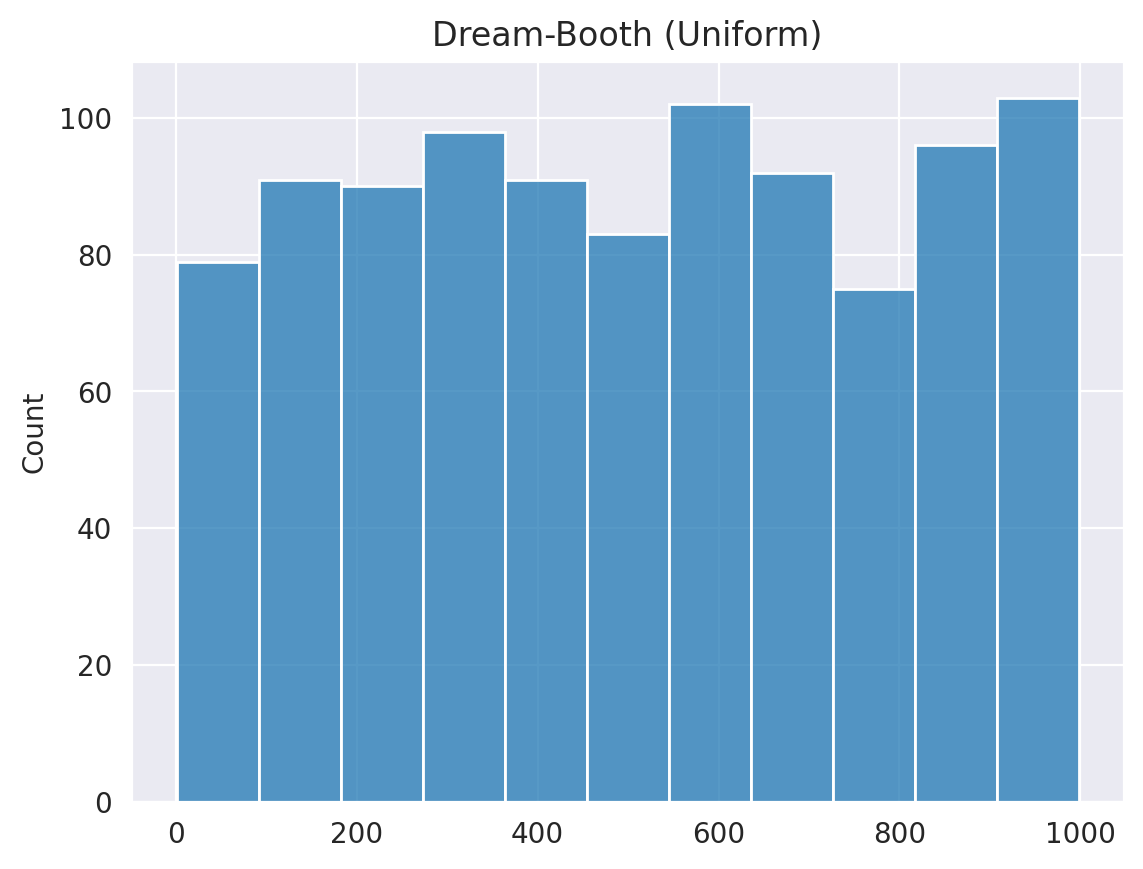

In [ ]:
idx =  torch.randint(0, 1000, (1000, ))
ax = sns.histplot(idx)
ax.set_title("Dream-Booth (Uniform)")

In [3]:
def sample_timesteps_power(T, bsz, alpha=3.0, device="cpu"):
    """
    Sample timesteps with power bias toward later (low-noise) steps.
    T: total number of timesteps
    bsz: batch size
    alpha: bias strength (bigger => more samples near t=0)
    """
    t = torch.arange(T, dtype=torch.float32, device=device)
    tau = t / (T - 1)                      # normalize 0..1
    probs = (1.0 - tau) ** alpha   # bias distribution
    probs = probs / probs.sum()            # normalize to sum=1
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

Text(0.5, 1.0, 'Left P-LoRA')

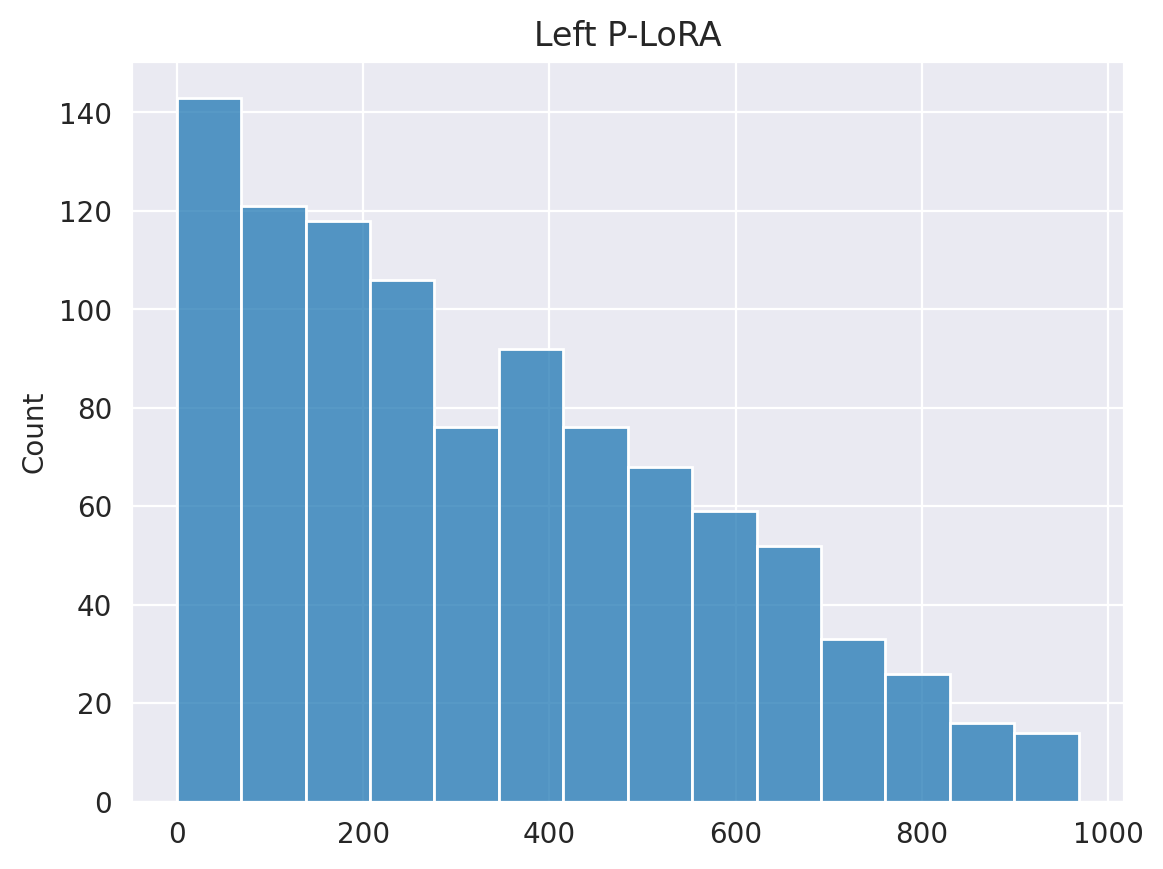

In [20]:
idx, probs = sample_timesteps_power(1000, 1000, alpha=1, device="cpu")
ax = sns.histplot(idx)
ax.set_title("Left P-LoRA")

In [5]:
def sample_timesteps_power_right_tail(T, bsz, alpha=3.0, device="cpu"):
    """
    Sample timesteps with power bias toward earlier (high-noise) steps.
    T: total number of timesteps
    bsz: batch size
    alpha: bias strength (bigger => more samples near t=T-1)
    """
    t = torch.arange(T, dtype=torch.float32, device=device)
    tau = t / (T - 1)                     # normalize 0..1
    probs = tau ** alpha                  # bias toward large t
    probs = probs / probs.sum()           # normalize
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

Text(0.5, 1.0, 'Right P-LoRA')

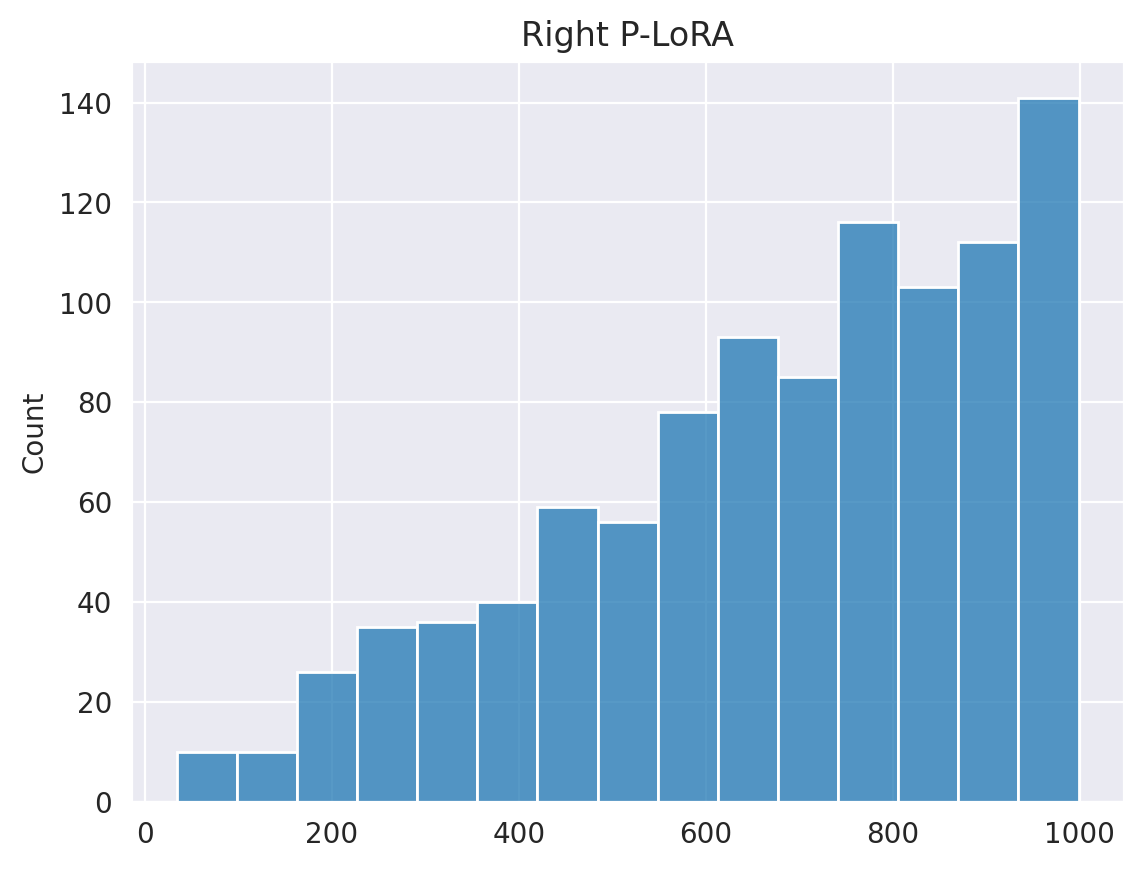

In [22]:
idx, probs = sample_timesteps_power_right_tail(1000, 1000, alpha=1, device="cpu")
ax = sns.histplot(idx)
ax.set_title("Right P-LoRA")

In [8]:
def sample_timesteps_beta(T, bsz, alpha=2.0, beta=2.0, device="cpu"):
    t = torch.arange(T, dtype=torch.float32, device=device)
    # Midpoint discretization: tau in (0.5/T, ..., (T-0.5)/T), never 0 or 1.
    tau = (t + 0.5) / T
    log_p = (alpha - 1) * torch.log(tau) + (beta - 1) * torch.log(1 - tau)
    log_p = log_p - log_p.max()  # numerical stability
    probs = torch.exp(log_p)
    probs = probs / probs.sum()
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

Text(0.5, 1.0, 'U-Shaped P-LoRA')

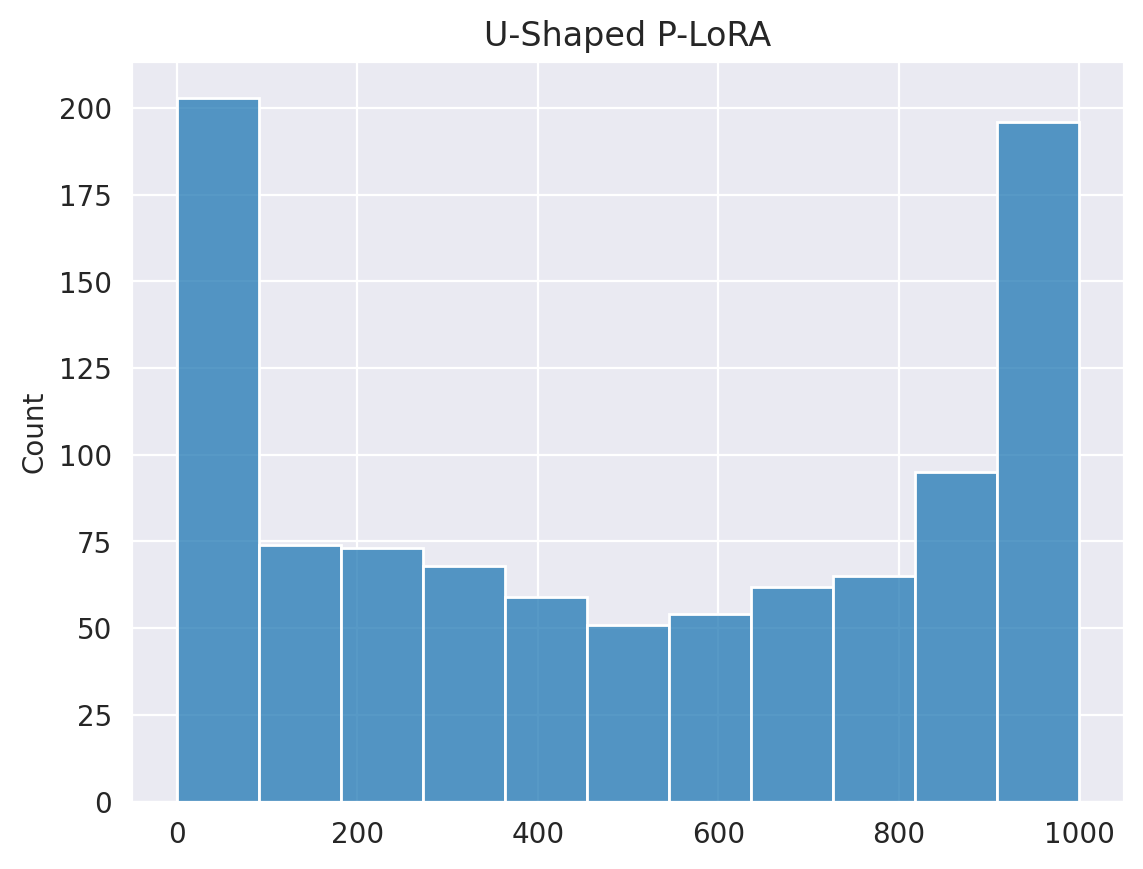

In [25]:
idx, probs = sample_timesteps_beta(1000, 1000, alpha=0.5, beta=0.5, device="cpu")
ax = sns.histplot(idx)
ax.set_title("U-Shaped P-LoRA")

Text(0.5, 1.0, 'Center P-LoRA')

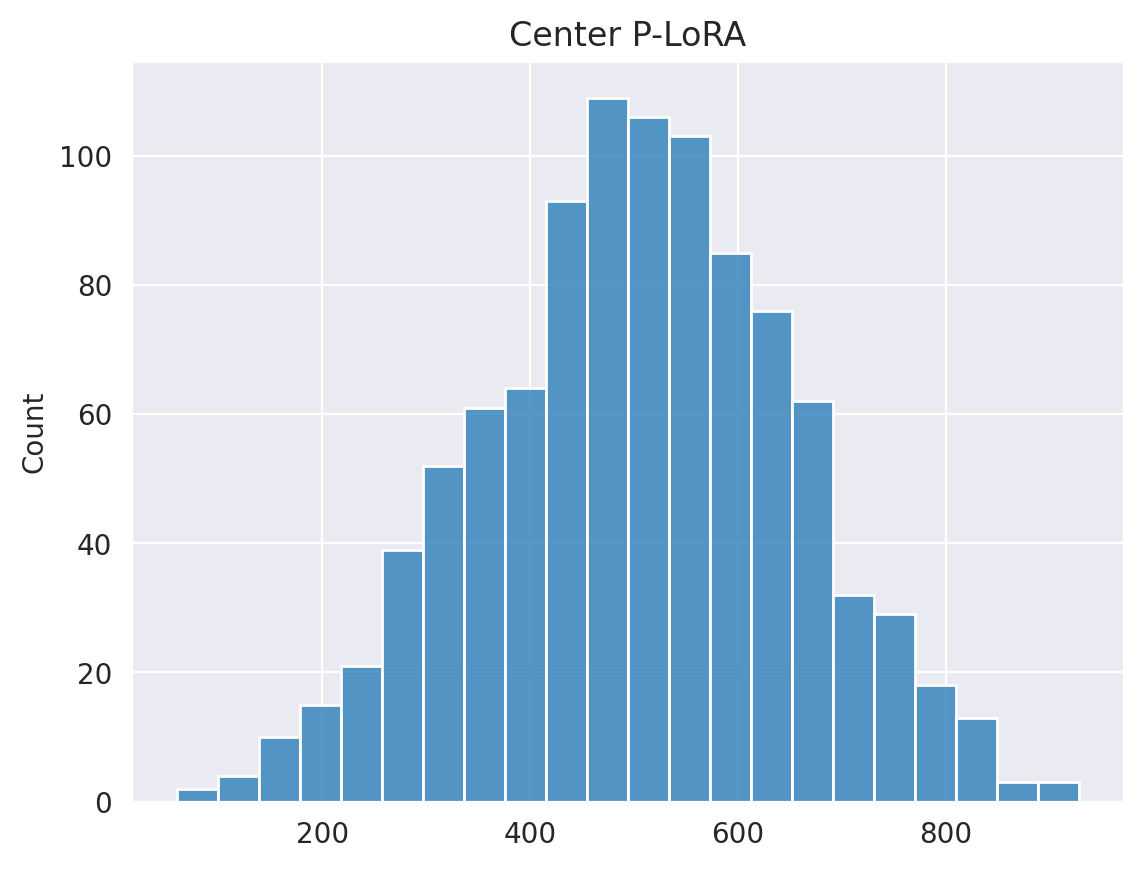

In [27]:
idx, probs = sample_timesteps_beta(1000, 1000, alpha=5, beta=5, device="cpu")
ax = sns.histplot(idx)
ax.set_title("Center P-LoRA")

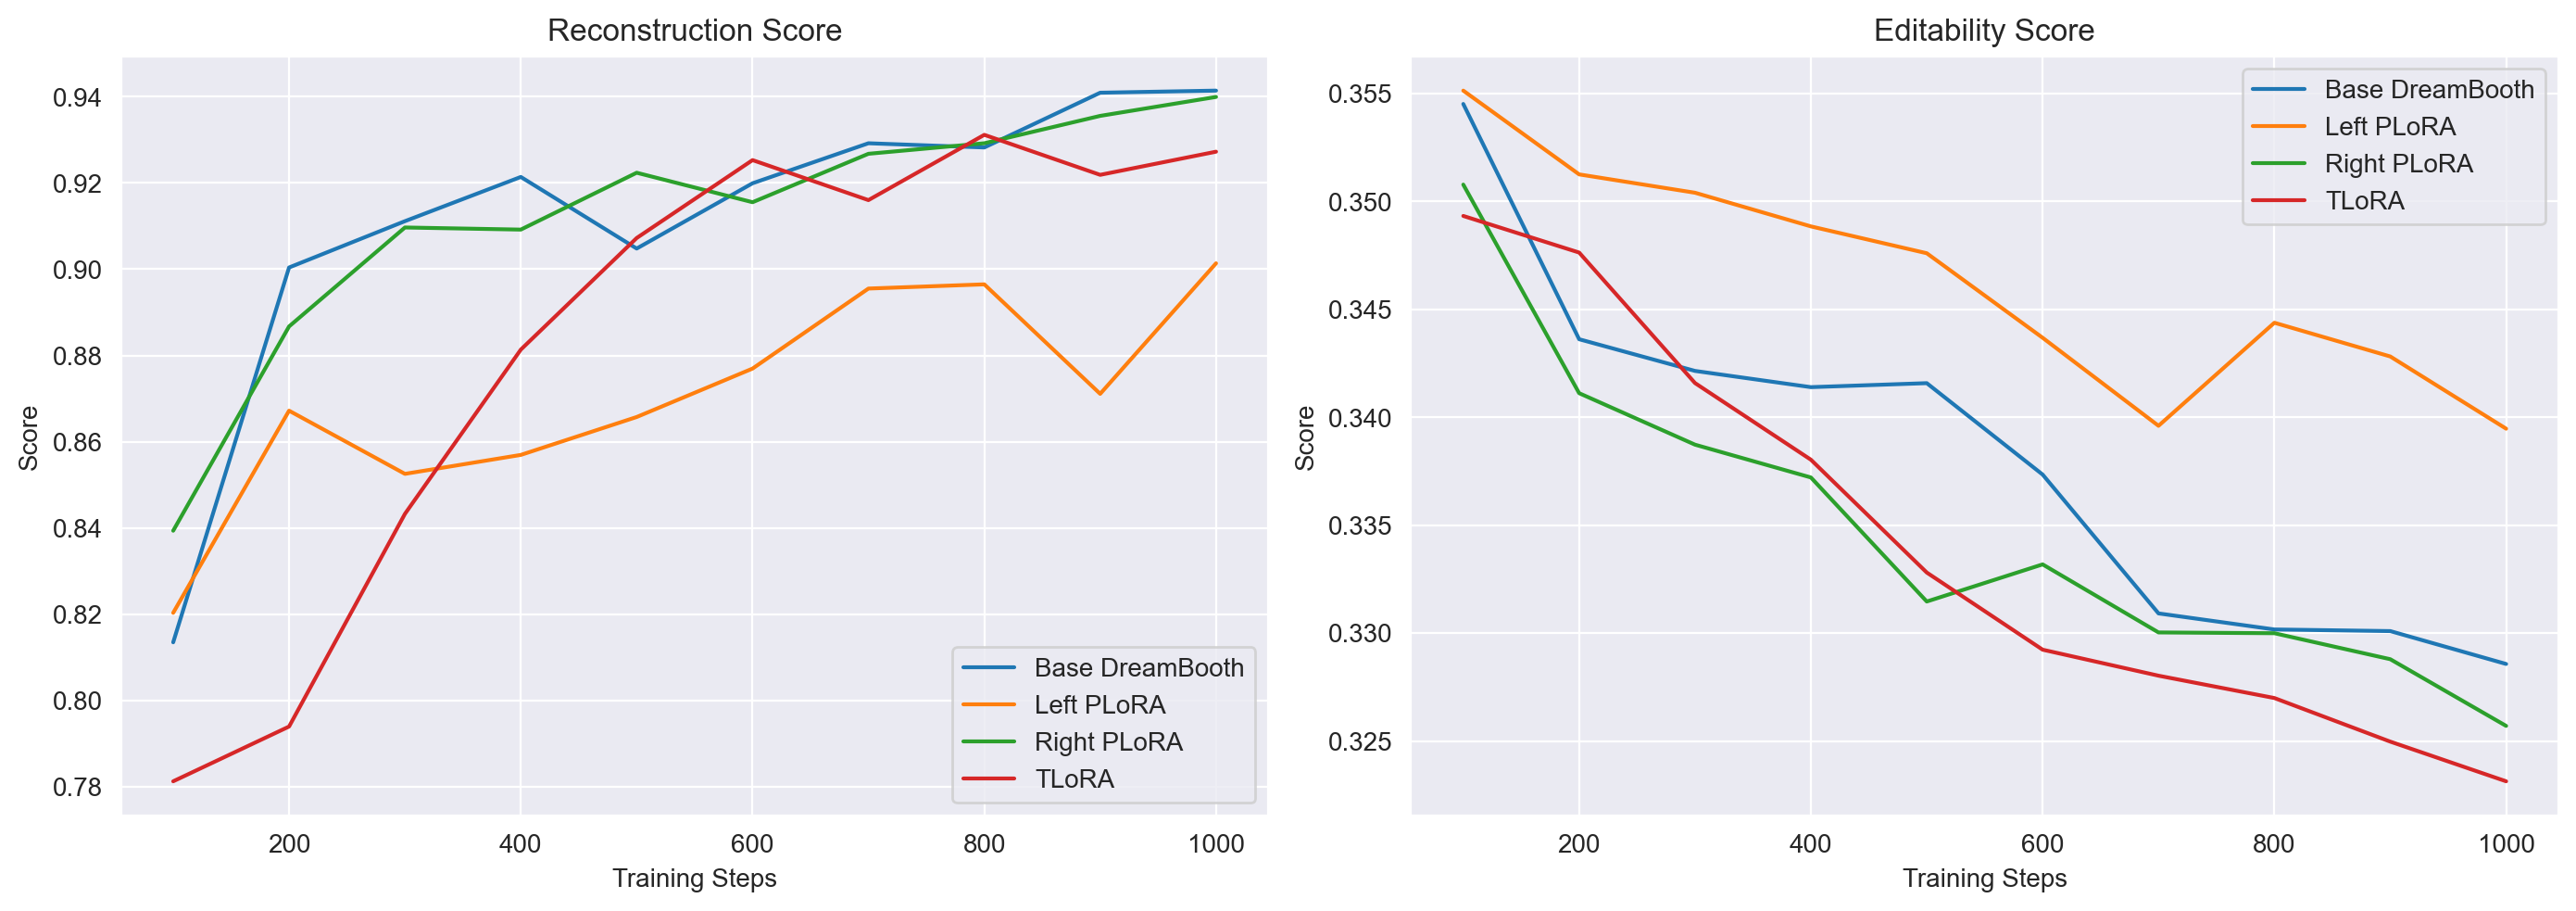

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# few_shot
base_rec_few = {100: 0.8134765625,
 200: 0.900390625,
 300: 0.9111328125,
 400: 0.92138671875,
 500: 0.90478515625,
 600: 0.919921875,
 700: 0.92919921875,
 800: 0.92822265625,
 900: 0.94091796875,
 1000: 0.94140625}

base_edit_few = {100: 0.35452368951612906,
 200: 0.34362005418346775,
 300: 0.3421512726814516,
 400: 0.34139916204637094,
 500: 0.34158423639112906,
 600: 0.3373472152217742,
 700: 0.3309129284274194,
 800: 0.33016869329637094,
 900: 0.3300938760080645,
 1000: 0.32856996597782256}

left_rec_few = {100: 0.8203125,
 200: 0.8671875,
 300: 0.8525390625,
 400: 0.85693359375,
 500: 0.86572265625,
 600: 0.876953125,
 700: 0.8955078125,
 800: 0.896484375,
 900: 0.87109375,
 1000: 0.9013671875}

left_edit_few = {100: 0.3551419165826613,
 200: 0.35125929309475806,
 300: 0.3504087386592742,
 400: 0.3488493888608871,
 500: 0.3476050592237903,
 600: 0.34368699596774194,
 700: 0.33960748487903225,
 800: 0.34438397807459675,
 900: 0.34282069052419356,
 1000: 0.3394736013104839}

right_rec_few = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

right_edit_few = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}

tlora_rec_few = {100: 0.78125,
 200: 0.7939453125,
 300: 0.84326171875,
 400: 0.88134765625,
 500: 0.9072265625,
 600: 0.92529296875,
 700: 0.916015625,
 800: 0.93115234375,
 900: 0.921875,
 1000: 0.92724609375}

tlora_edit_few = {100: 0.34933373235887094,
 200: 0.3476365612399194,
 300: 0.3415881741431452,
 400: 0.33803632182459675,
 500: 0.33280698714717744,
 600: 0.32923150831653225,
 700: 0.32802655619959675,
 800: 0.3269909274193548,
 900: 0.3249708606350806,
 1000: 0.3231319304435484}

# ---- PLOTTING ----
steps = list(base_rec_few.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_few.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_few.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_few.values(), label="Right PLoRA")
axs[0].plot(steps, tlora_rec_few.values(), label="TLoRA")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit_few.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit_few.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit_few.values(), label="Right PLoRA")
axs[1].plot(steps, tlora_edit_few.values(), label="TLoRA")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

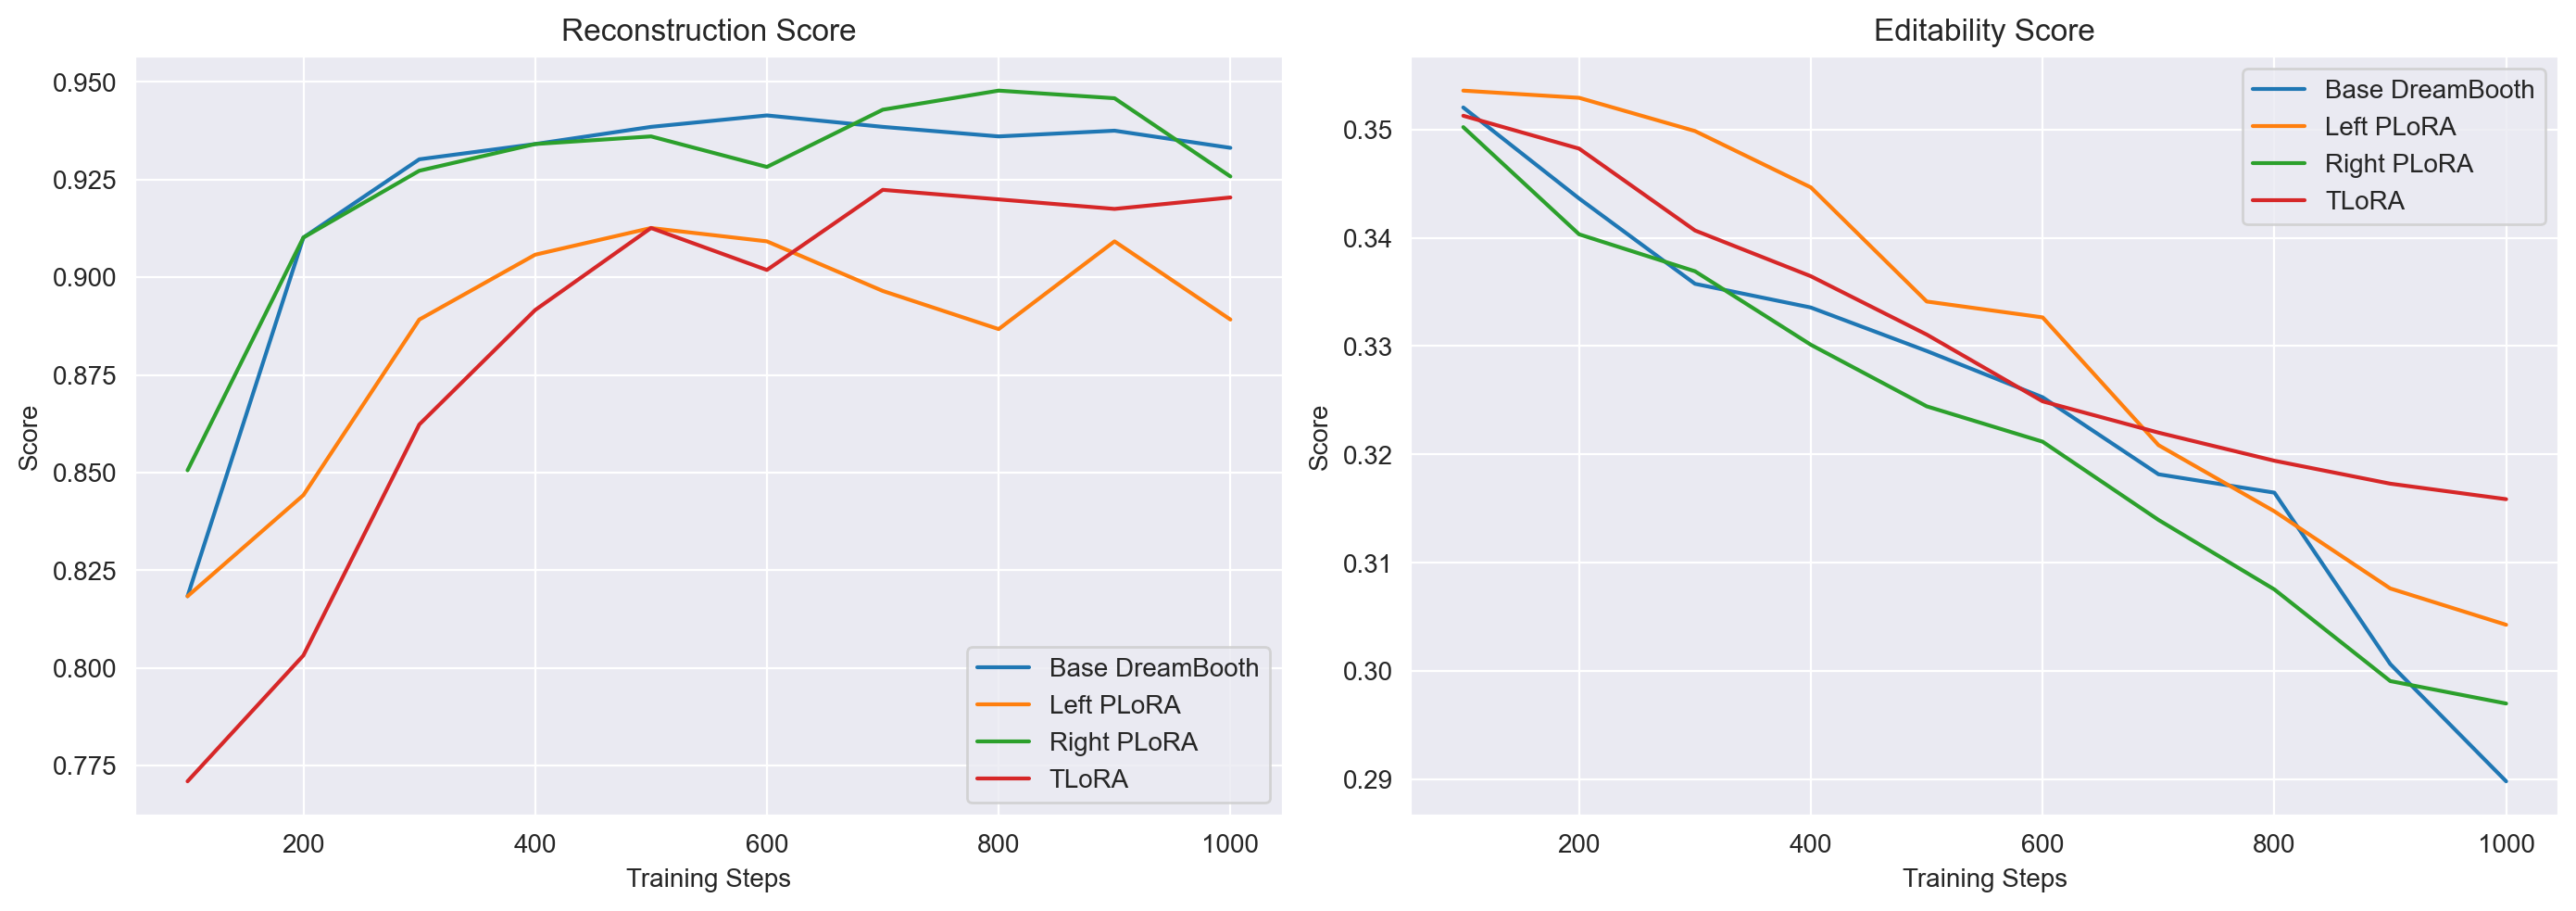

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# one shot

base_rec_one = {100: 0.818359375,
 200: 0.91015625,
 300: 0.93017578125,
 400: 0.93408203125,
 500: 0.9384765625,
 600: 0.94140625,
 700: 0.9384765625,
 800: 0.93603515625,
 900: 0.9375,
 1000: 0.93310546875}

base_edit_one = {100: 0.35202715473790325,
 200: 0.3436239919354839,
 300: 0.3357484879032258,
 400: 0.33355909778225806,
 500: 0.32954652847782256,
 600: 0.3252780052923387,
 700: 0.3181664251512097,
 800: 0.3164712229082661,
 900: 0.3006493353074597,
 1000: 0.2898283927671371}

left_rec_one = {100: 0.818359375,
 200: 0.84423828125,
 300: 0.88916015625,
 400: 0.90576171875,
 500: 0.91259765625,
 600: 0.9091796875,
 700: 0.896484375,
 800: 0.88671875,
 900: 0.9091796875,
 1000: 0.88916015625}

left_edit_one = {100: 0.3535825667842742,
 200: 0.3529170866935484,
 300: 0.3498495778729839,
 400: 0.34464780745967744,
 500: 0.33411432081653225,
 600: 0.33264947706653225,
 700: 0.3208578786542339,
 800: 0.3147484564012097,
 900: 0.3076290007560484,
 1000: 0.3042760049143145}

right_rec_one = {100: 0.8505859375,
 200: 0.91015625,
 300: 0.92724609375,
 400: 0.93408203125,
 500: 0.93603515625,
 600: 0.92822265625,
 700: 0.94287109375,
 800: 0.94775390625,
 900: 0.94580078125,
 1000: 0.92578125}

right_edit_one = {100: 0.3502157888104839,
 200: 0.3403162802419355,
 300: 0.33690618699596775,
 400: 0.33012144027217744,
 500: 0.32443926411290325,
 600: 0.32117486769153225,
 700: 0.3139549993699597,
 800: 0.30753843245967744,
 900: 0.29908014112903225,
 1000: 0.2970088835685484}

tlora_rec_one = {100: 0.77099609375,
 200: 0.80322265625,
 300: 0.8623046875,
 400: 0.8916015625,
 500: 0.91259765625,
 600: 0.90185546875,
 700: 0.92236328125,
 800: 0.919921875,
 900: 0.91748046875,
 1000: 0.92041015625}

tlora_edit_one = {100: 0.3512632308467742,
 200: 0.3482272240423387,
 300: 0.3406706779233871,
 400: 0.33644940776209675,
 500: 0.33106256300403225,
 600: 0.3248999810987903,
 700: 0.32201360887096775,
 800: 0.3194186302923387,
 900: 0.3173001197076613,
 1000: 0.3158687468497984}

# ---- PLOTTING ----
steps = list(base_rec_one.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_one.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_one.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_one.values(), label="Right PLoRA")
axs[0].plot(steps, tlora_rec_one.values(), label="TLoRA")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit_one.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit_one.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit_one.values(), label="Right PLoRA")
axs[1].plot(steps, tlora_edit_one.values(), label="TLoRA")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

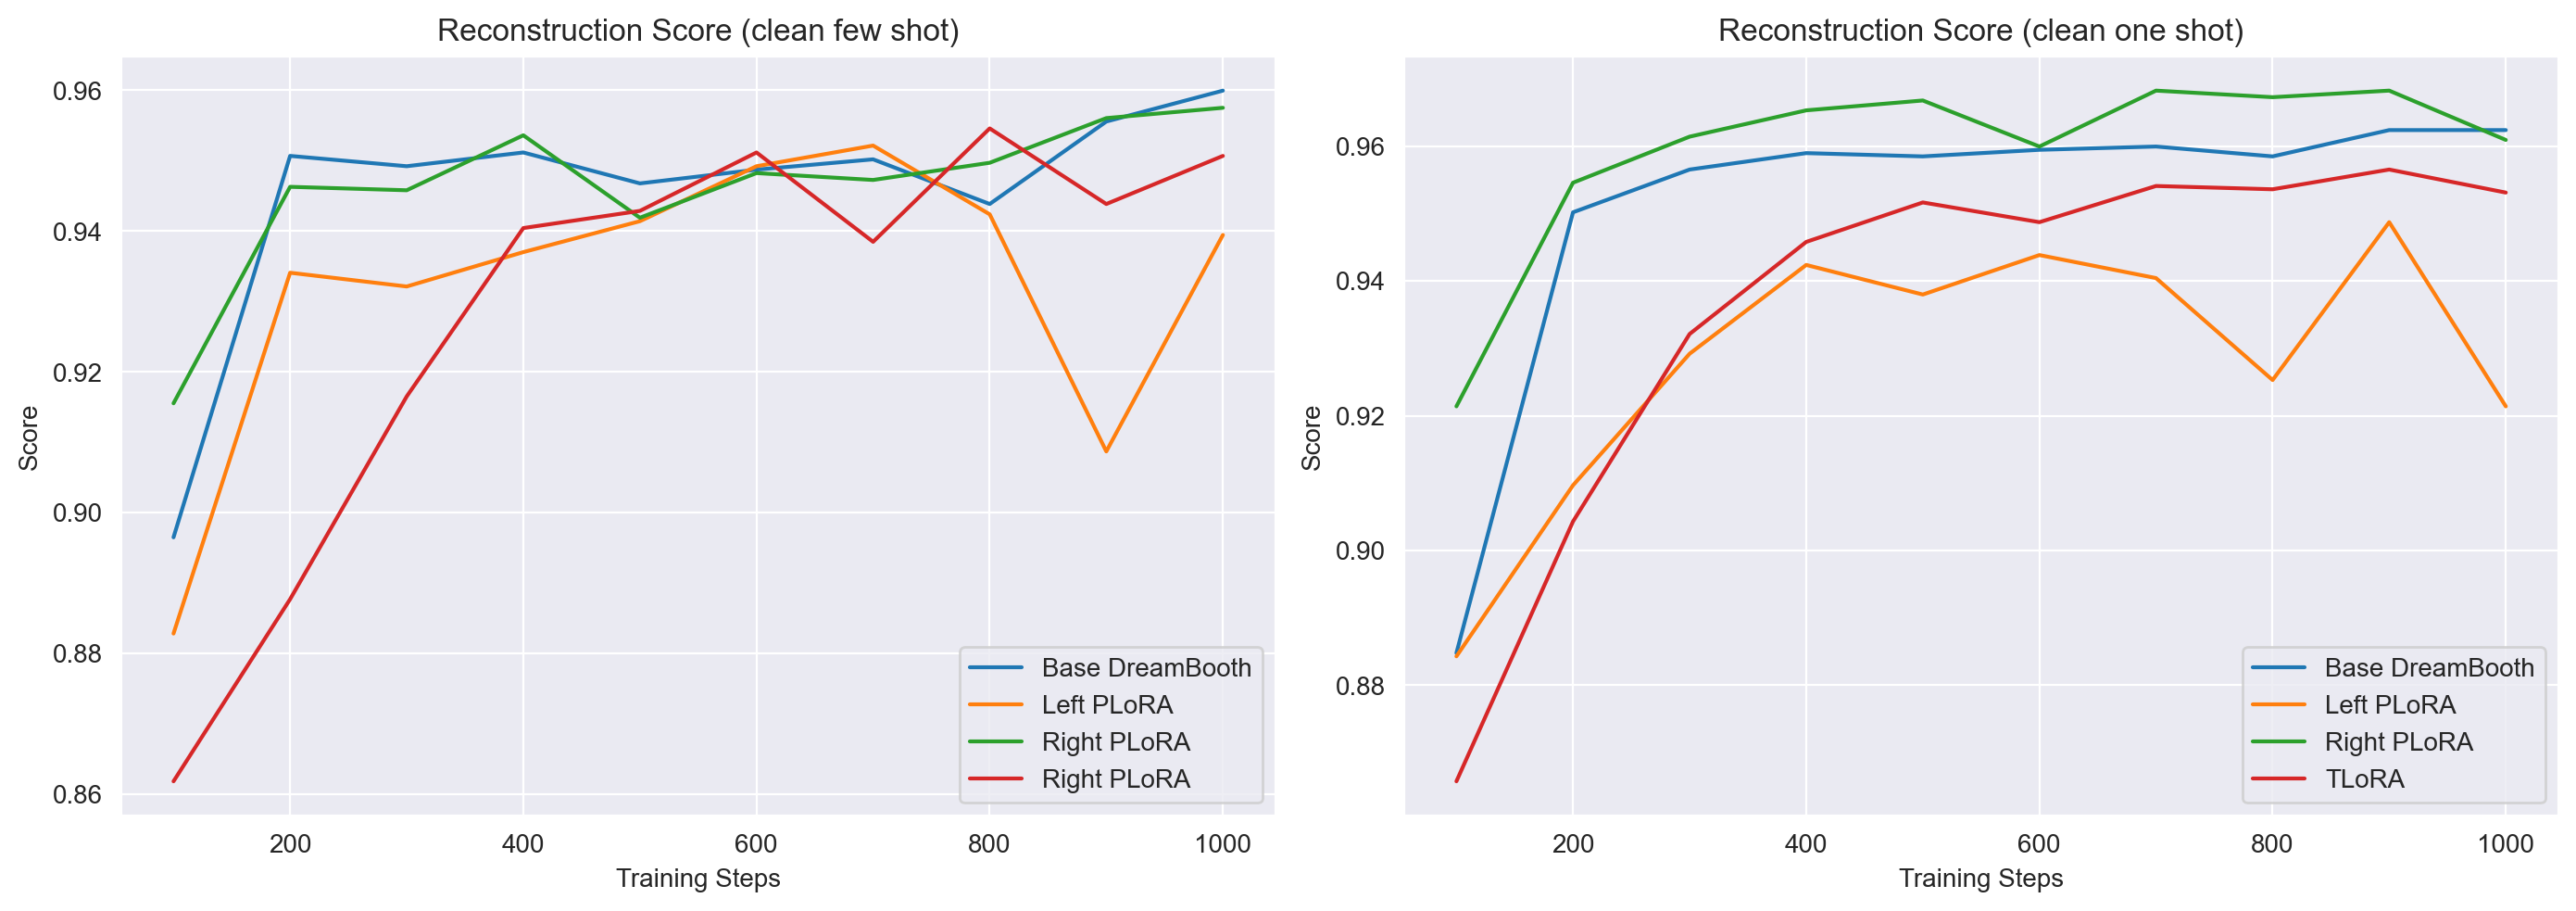

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# clean_images

base_rec_few_clean = {100: 0.896484375,
 200: 0.95068359375,
 300: 0.94921875,
 400: 0.951171875,
 500: 0.94677734375,
 600: 0.94873046875,
 700: 0.9501953125,
 800: 0.94384765625,
 900: 0.95556640625,
 1000: 0.9599609375}

base_rec_one_clean = {100: 0.884765625,
 200: 0.9501953125,
 300: 0.95654296875,
 400: 0.958984375,
 500: 0.95849609375,
 600: 0.95947265625,
 700: 0.9599609375,
 800: 0.95849609375,
 900: 0.96240234375,
 1000: 0.96240234375}

left_rec_few_clean={100: 0.8828125,
 200: 0.93408203125,
 300: 0.93212890625,
 400: 0.93701171875,
 500: 0.94140625,
 600: 0.94921875,
 700: 0.9521484375,
 800: 0.9423828125,
 900: 0.90869140625,
 1000: 0.939453125}

left_rec_one_clean = {100: 0.88427734375,
 200: 0.90966796875,
 300: 0.92919921875,
 400: 0.9423828125,
 500: 0.93798828125,
 600: 0.94384765625,
 700: 0.9404296875,
 800: 0.92529296875,
 900: 0.94873046875,
 1000: 0.92138671875}

right_rec_few_clean = {100: 0.91552734375,
 200: 0.9462890625,
 300: 0.94580078125,
 400: 0.95361328125,
 500: 0.94189453125,
 600: 0.9482421875,
 700: 0.947265625,
 800: 0.94970703125,
 900: 0.9560546875,
 1000: 0.95751953125}

right_rec_one_clean = {100: 0.92138671875,
 200: 0.95458984375,
 300: 0.96142578125,
 400: 0.96533203125,
 500: 0.966796875,
 600: 0.9599609375,
 700: 0.96826171875,
 800: 0.96728515625,
 900: 0.96826171875,
 1000: 0.9609375}

tlora_rec_few_clean = {100: 0.86181640625,
 200: 0.8876953125,
 300: 0.91650390625,
 400: 0.9404296875,
 500: 0.94287109375,
 600: 0.951171875,
 700: 0.9384765625,
 800: 0.95458984375,
 900: 0.94384765625,
 1000: 0.95068359375}

tlora_rec_one_clean = {100: 0.86572265625,
 200: 0.904296875,
 300: 0.93212890625,
 400: 0.94580078125,
 500: 0.95166015625,
 600: 0.94873046875,
 700: 0.9541015625,
 800: 0.95361328125,
 900: 0.95654296875,
 1000: 0.953125}


 # ---- PLOTTING ----
steps = list(base_rec_few_clean.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_few_clean.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_few_clean.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_few_clean.values(), label="Right PLoRA")
axs[0].plot(steps, tlora_rec_few_clean.values(), label="Right PLoRA")

axs[0].set_title("Reconstruction Score (clean few shot)")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_rec_one_clean.values(), label="Base DreamBooth")
axs[1].plot(steps, left_rec_one_clean.values(), label="Left PLoRA")
axs[1].plot(steps, right_rec_one_clean.values(), label="Right PLoRA")
axs[1].plot(steps, tlora_rec_one_clean.values(), label="TLoRA")

axs[1].set_title("Reconstruction Score (clean one shot)")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

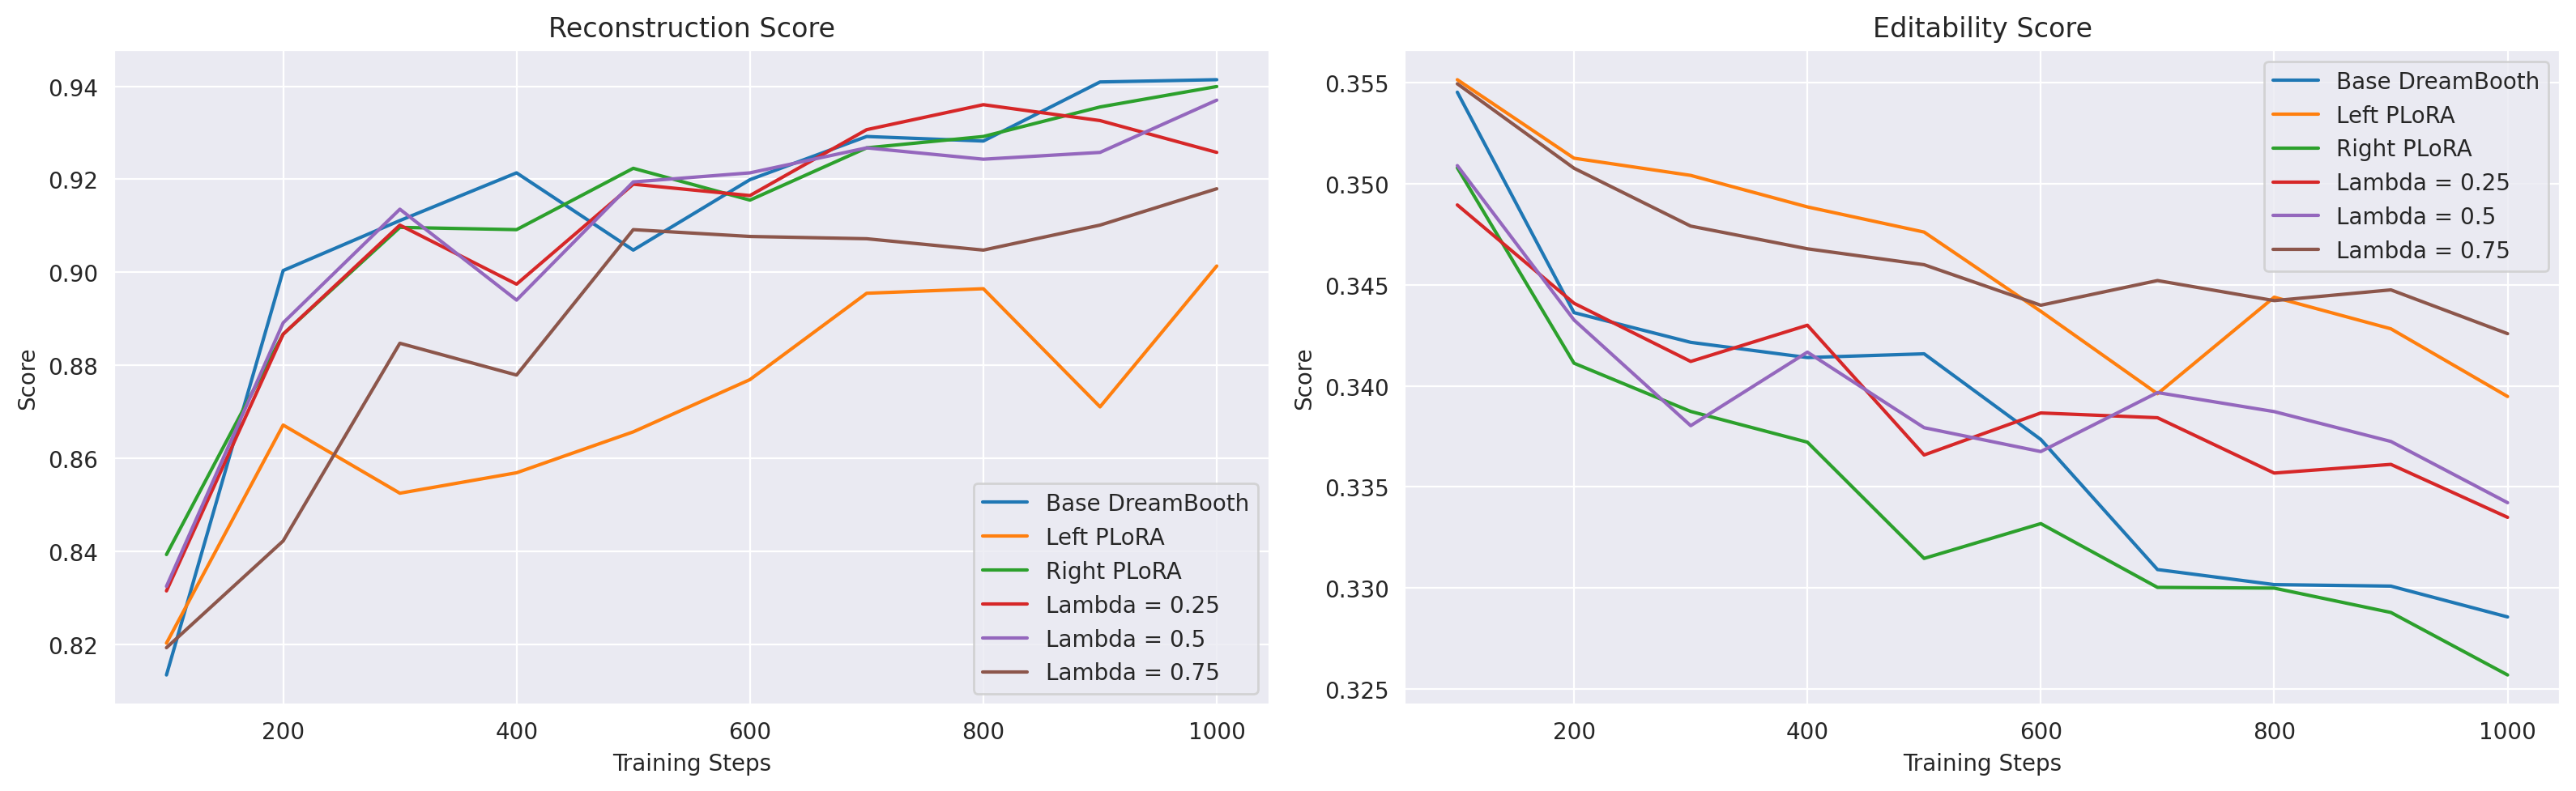

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# few_shot
base_rec_few = {100: 0.8134765625,
 200: 0.900390625,
 300: 0.9111328125,
 400: 0.92138671875,
 500: 0.90478515625,
 600: 0.919921875,
 700: 0.92919921875,
 800: 0.92822265625,
 900: 0.94091796875,
 1000: 0.94140625}

base_edit_few = {100: 0.35452368951612906,
 200: 0.34362005418346775,
 300: 0.3421512726814516,
 400: 0.34139916204637094,
 500: 0.34158423639112906,
 600: 0.3373472152217742,
 700: 0.3309129284274194,
 800: 0.33016869329637094,
 900: 0.3300938760080645,
 1000: 0.32856996597782256}

left_rec_few = {100: 0.8203125,
 200: 0.8671875,
 300: 0.8525390625,
 400: 0.85693359375,
 500: 0.86572265625,
 600: 0.876953125,
 700: 0.8955078125,
 800: 0.896484375,
 900: 0.87109375,
 1000: 0.9013671875}

left_edit_few = {100: 0.3551419165826613,
 200: 0.35125929309475806,
 300: 0.3504087386592742,
 400: 0.3488493888608871,
 500: 0.3476050592237903,
 600: 0.34368699596774194,
 700: 0.33960748487903225,
 800: 0.34438397807459675,
 900: 0.34282069052419356,
 1000: 0.3394736013104839}

right_rec_few = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

right_edit_few = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}

# lambda = 0.25
lambda25_rec = {100: 0.83154296875,
 200: 0.88671875,
 300: 0.91015625,
 400: 0.8974609375,
 500: 0.9189453125,
 600: 0.91650390625,
 700: 0.9306640625,
 800: 0.93603515625,
 900: 0.9326171875,
 1000: 0.92578125}

# lambda = 0.5
lambda50_rec = {100: 0.83251953125,
 200: 0.88916015625,
 300: 0.91357421875,
 400: 0.89404296875,
 500: 0.91943359375,
 600: 0.92138671875,
 700: 0.9267578125,
 800: 0.92431640625,
 900: 0.92578125,
 1000: 0.93701171875}

# lambda = 0.75
lambda75_rec = {100: 0.8193359375,
 200: 0.84228515625,
 300: 0.884765625,
 400: 0.8779296875,
 500: 0.9091796875,
 600: 0.90771484375,
 700: 0.9072265625,
 800: 0.90478515625,
 900: 0.91015625,
 1000: 0.91796875}

# lambda = 0.25
lambda25_edit = {100: 0.3489478326612903,
 200: 0.34408470892137094,
 300: 0.3412062121975806,
 400: 0.3429978893649194,
 500: 0.33657935357862906,
 600: 0.3386584866431452,
 700: 0.33842222152217744,
 800: 0.33568548387096775,
 900: 0.3361146988407258,
 1000: 0.33349609375}

# lambda = 0.50
lambda50_edit = {100: 0.35089308215725806,
 200: 0.3432577809979839,
 300: 0.3380284463205645,
 400: 0.34166692918346775,
 500: 0.3379300025201613,
 600: 0.33674867691532256,
 700: 0.3396665511592742,
 800: 0.3387254284274194,
 900: 0.33724877142137094,
 1000: 0.33422064012096775}


# lambda = 0.75
lambda75_edit = {100: 0.3549410912298387,
 200: 0.3507631363407258,
 300: 0.347900390625,
 400: 0.34677813130040325,
 500: 0.34599058089717744,
 600: 0.34398626512096775,
 700: 0.34520696824596775,
 800: 0.34421465473790325,
 900: 0.3447462512600806,
 1000: 0.3425804876512097}


steps = list(base_rec_few.keys())

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# =========================
# Reconstruction Score
# =========================
axs[0].plot(steps, base_rec_few.values(),label="Base DreamBooth")
axs[0].plot(steps, left_rec_few.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_few.values(), label="Right PLoRA")

axs[0].plot(steps, lambda25_rec.values(), label="Lambda = 0.25")
axs[0].plot(steps, lambda50_rec.values(), label="Lambda = 0.5")
axs[0].plot(steps, lambda75_rec.values(), label="Lambda = 0.75")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# =========================
# Editability Score
# =========================
axs[1].plot(steps, base_edit_few.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit_few.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit_few.values(), label="Right PLoRA")

axs[1].plot(steps, lambda25_edit.values(), label="Lambda = 0.25")
axs[1].plot(steps, lambda50_edit.values(), label="Lambda = 0.5")
axs[1].plot(steps, lambda75_edit.values(), label="Lambda = 0.75")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

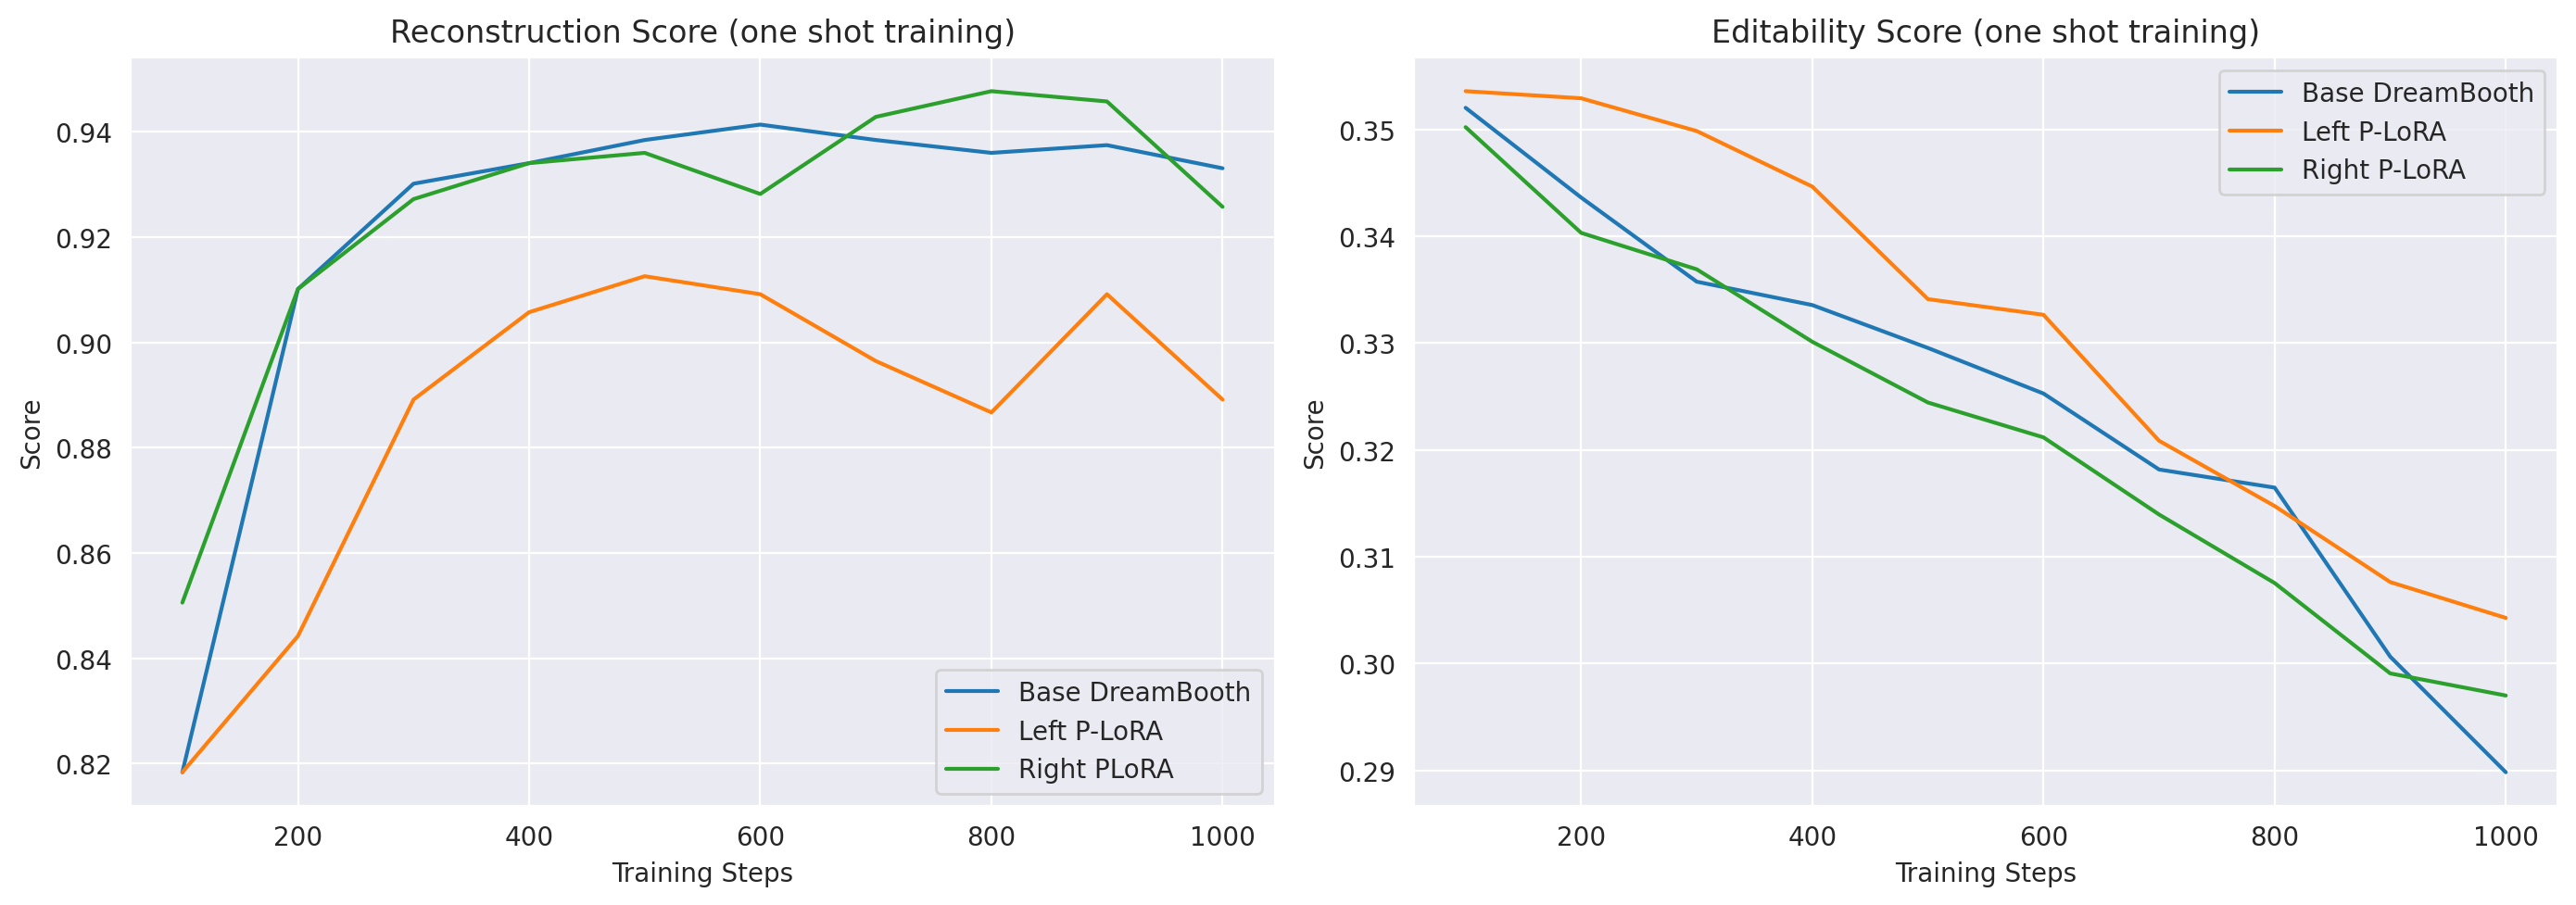

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# one shot

base_rec_one = {100: 0.818359375,
 200: 0.91015625,
 300: 0.93017578125,
 400: 0.93408203125,
 500: 0.9384765625,
 600: 0.94140625,
 700: 0.9384765625,
 800: 0.93603515625,
 900: 0.9375,
 1000: 0.93310546875}

base_edit_one = {100: 0.35202715473790325,
 200: 0.3436239919354839,
 300: 0.3357484879032258,
 400: 0.33355909778225806,
 500: 0.32954652847782256,
 600: 0.3252780052923387,
 700: 0.3181664251512097,
 800: 0.3164712229082661,
 900: 0.3006493353074597,
 1000: 0.2898283927671371}

left_rec_one = {100: 0.818359375,
 200: 0.84423828125,
 300: 0.88916015625,
 400: 0.90576171875,
 500: 0.91259765625,
 600: 0.9091796875,
 700: 0.896484375,
 800: 0.88671875,
 900: 0.9091796875,
 1000: 0.88916015625}

left_edit_one = {100: 0.3535825667842742,
 200: 0.3529170866935484,
 300: 0.3498495778729839,
 400: 0.34464780745967744,
 500: 0.33411432081653225,
 600: 0.33264947706653225,
 700: 0.3208578786542339,
 800: 0.3147484564012097,
 900: 0.3076290007560484,
 1000: 0.3042760049143145}

right_rec_one = {100: 0.8505859375,
 200: 0.91015625,
 300: 0.92724609375,
 400: 0.93408203125,
 500: 0.93603515625,
 600: 0.92822265625,
 700: 0.94287109375,
 800: 0.94775390625,
 900: 0.94580078125,
 1000: 0.92578125}

right_edit_one = {100: 0.3502157888104839,
 200: 0.3403162802419355,
 300: 0.33690618699596775,
 400: 0.33012144027217744,
 500: 0.32443926411290325,
 600: 0.32117486769153225,
 700: 0.3139549993699597,
 800: 0.30753843245967744,
 900: 0.29908014112903225,
 1000: 0.2970088835685484}


# ---- PLOTTING ----
steps = list(base_rec_one.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_one.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_one.values(), label="Left P-LoRA")
axs[0].plot(steps, right_rec_one.values(), label="Right PLoRA")
# axs[0].plot(steps, tlora_rec_one.values(), label="TLoRA")

axs[0].set_title("Reconstruction Score (one shot training)")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit_one.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit_one.values(), label="Left P-LoRA")
axs[1].plot(steps, right_edit_one.values(), label="Right P-LoRA")
# axs[1].plot(steps, tlora_edit_one.values(), label="TLoRA")

axs[1].set_title("Editability Score (one shot training)")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

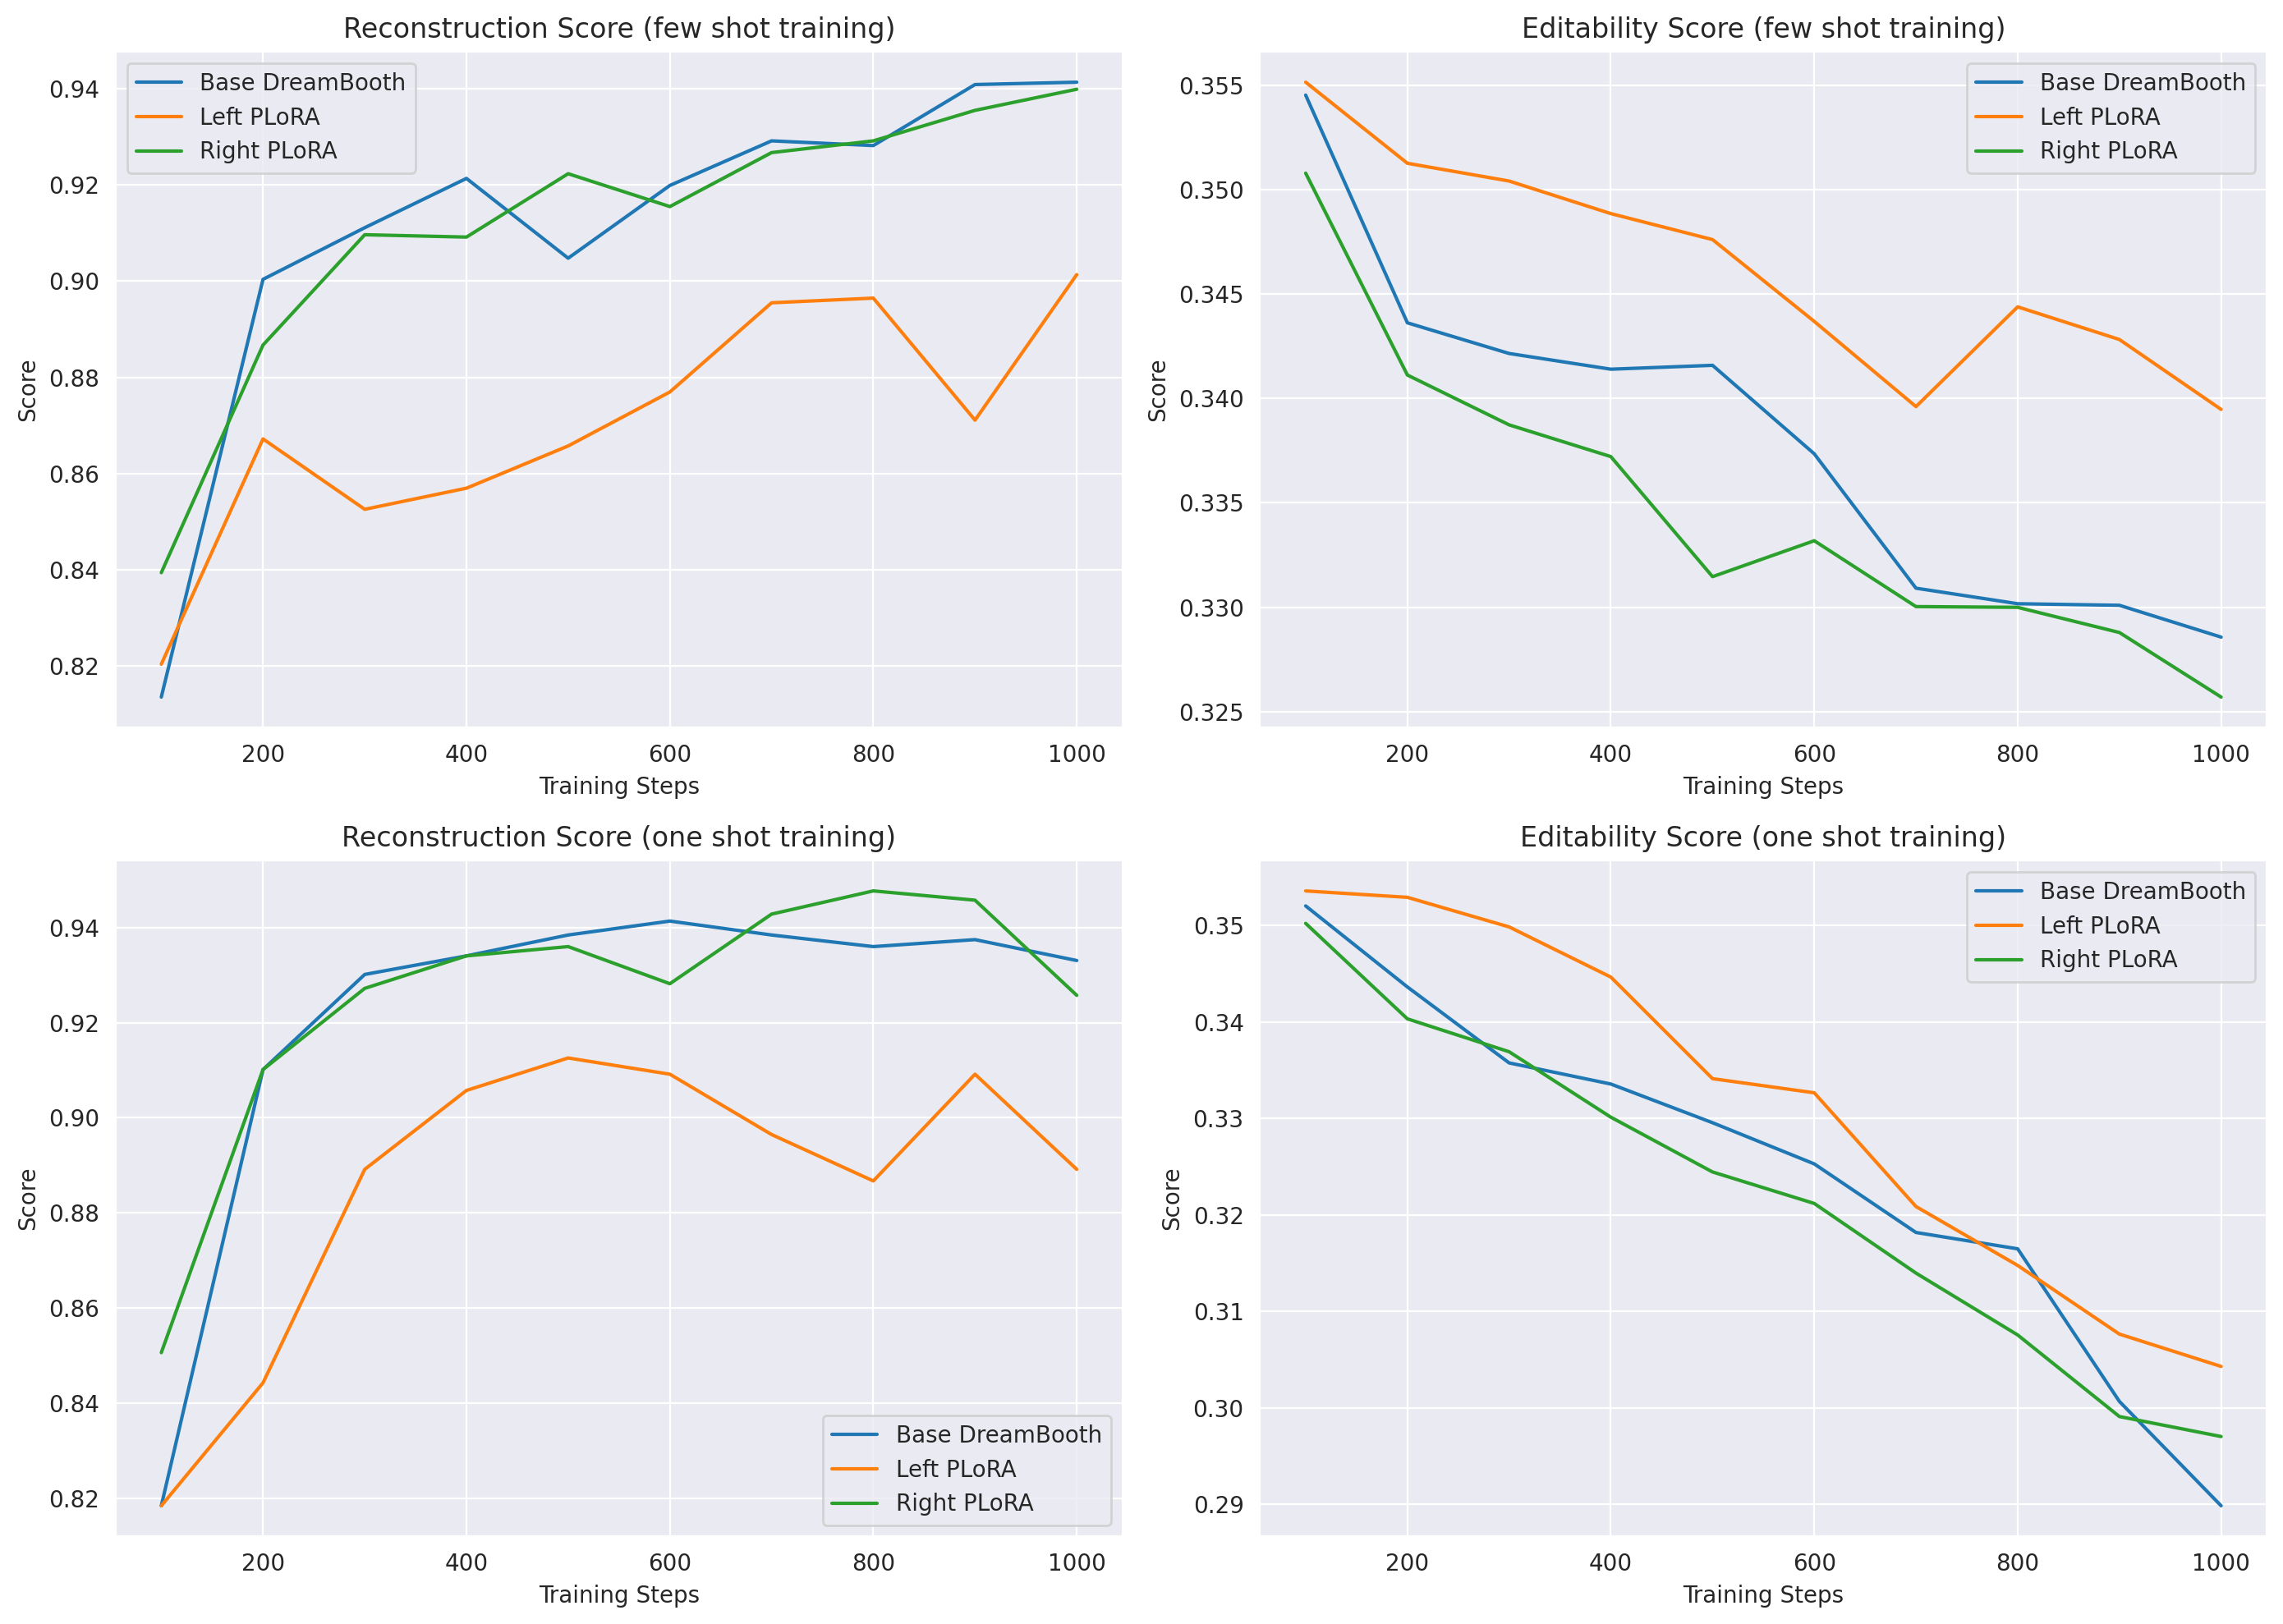

In [16]:
steps = list(base_rec_few.keys())

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Reconstruction few-shot ---
axs[0, 0].plot(steps, base_rec_few.values(), label="Base DreamBooth")
axs[0, 0].plot(steps, left_rec_few.values(), label="Left PLoRA")
axs[0, 0].plot(steps, right_rec_few.values(), label="Right PLoRA")

axs[0, 0].set_title("Reconstruction Score (few shot training)")
axs[0, 0].set_xlabel("Training Steps")
axs[0, 0].set_ylabel("Score")
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- Editability few-shot ---
axs[0, 1].plot(steps, base_edit_few.values(), label="Base DreamBooth")
axs[0, 1].plot(steps, left_edit_few.values(), label="Left PLoRA")
axs[0, 1].plot(steps, right_edit_few.values(), label="Right PLoRA")

axs[0, 1].set_title("Editability Score (few shot training)")
axs[0, 1].set_xlabel("Training Steps")
axs[0, 1].set_ylabel("Score")
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- Reconstruction one-shot ---
axs[1, 0].plot(steps, base_rec_one.values(), label="Base DreamBooth")
axs[1, 0].plot(steps, left_rec_one.values(), label="Left PLoRA")
axs[1, 0].plot(steps, right_rec_one.values(), label="Right PLoRA")

axs[1, 0].set_title("Reconstruction Score (one shot training)")
axs[1, 0].set_xlabel("Training Steps")
axs[1, 0].set_ylabel("Score")
axs[1, 0].legend()
axs[1, 0].grid(True)

# --- Editability one-shot ---
axs[1, 1].plot(steps, base_edit_one.values(), label="Base DreamBooth")
axs[1, 1].plot(steps, left_edit_one.values(), label="Left PLoRA")
axs[1, 1].plot(steps, right_edit_one.values(), label="Right PLoRA")

axs[1, 1].set_title("Editability Score (one shot training)")
axs[1, 1].set_xlabel("Training Steps")
axs[1, 1].set_ylabel("Score")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

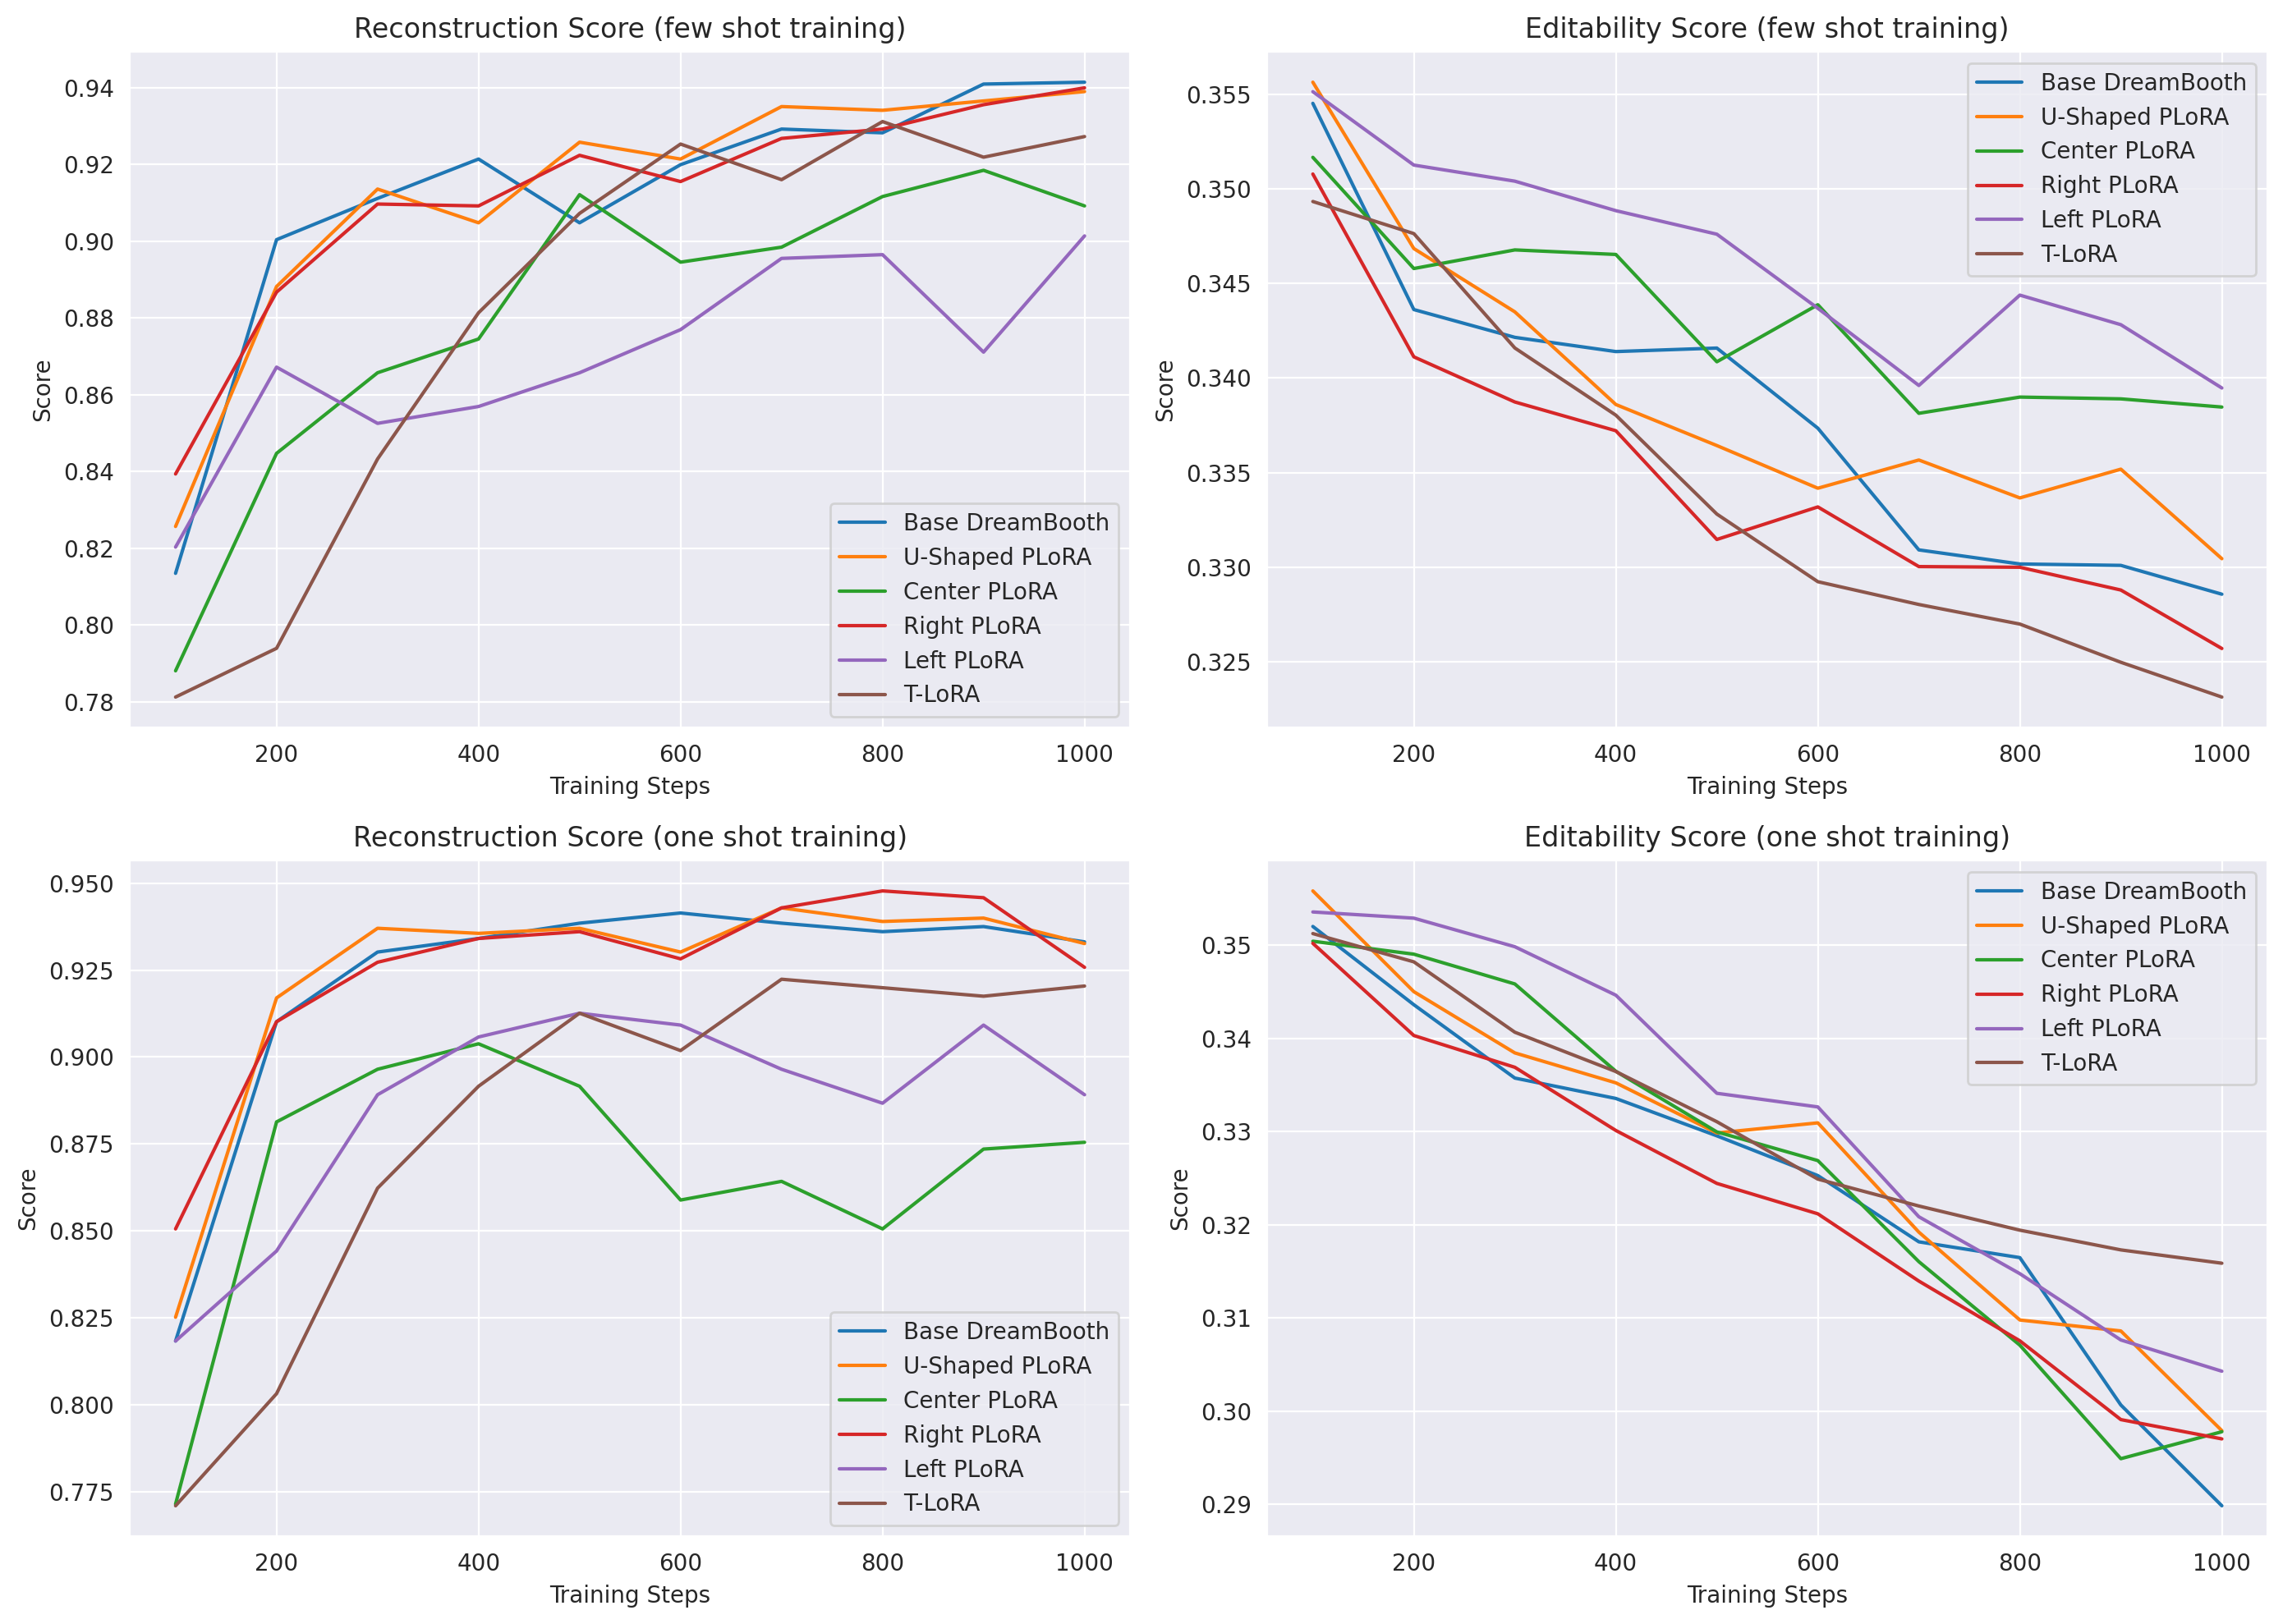

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

base_rec_few = {100: 0.8134765625,
 200: 0.900390625,
 300: 0.9111328125,
 400: 0.92138671875,
 500: 0.90478515625,
 600: 0.919921875,
 700: 0.92919921875,
 800: 0.92822265625,
 900: 0.94091796875,
 1000: 0.94140625}

base_edit_few = {100: 0.35452368951612906,
 200: 0.34362005418346775,
 300: 0.3421512726814516,
 400: 0.34139916204637094,
 500: 0.34158423639112906,
 600: 0.3373472152217742,
 700: 0.3309129284274194,
 800: 0.33016869329637094,
 900: 0.3300938760080645,
 1000: 0.32856996597782256}

u_shaped_rec = {100: 0.82568359375,
 200: 0.88818359375,
 300: 0.91357421875,
 400: 0.90478515625,
 500: 0.92578125,
 600: 0.92138671875,
 700: 0.93505859375,
 800: 0.93408203125,
 900: 0.9365234375,
 1000: 0.93896484375}

center_rec = {100: 0.7880859375,
 200: 0.8447265625,
 300: 0.86572265625,
 400: 0.87451171875,
 500: 0.912109375,
 600: 0.89453125,
 700: 0.8984375,
 800: 0.91162109375,
 900: 0.91845703125,
 1000: 0.9091796875}


u_shaped_edit = {100: 0.3556420110887097,
 200: 0.34684507308467744,
 300: 0.34349798387096775,
 400: 0.33859942036290325,
 500: 0.3364297190020161,
 600: 0.3341733870967742,
 700: 0.3356657951108871,
 800: 0.33366147933467744,
 900: 0.33518145161290325,
 1000: 0.3304482736895161}

center_edit = {100: 0.3516688193044355,
 200: 0.3457897555443548,
 300: 0.3467741935483871,
 400: 0.34653399067540325,
 500: 0.3408596900201613,
 600: 0.3438760080645161,
 700: 0.338134765625,
 800: 0.3389931955645161,
 900: 0.33889868951612906,
 1000: 0.3384655367943548}

right_rec_few = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

right_edit_few = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}


left_rec_few = {100: 0.8203125,
 200: 0.8671875,
 300: 0.8525390625,
 400: 0.85693359375,
 500: 0.86572265625,
 600: 0.876953125,
 700: 0.8955078125,
 800: 0.896484375,
 900: 0.87109375,
 1000: 0.9013671875}

left_edit_few = {100: 0.3551419165826613,
 200: 0.35125929309475806,
 300: 0.3504087386592742,
 400: 0.3488493888608871,
 500: 0.3476050592237903,
 600: 0.34368699596774194,
 700: 0.33960748487903225,
 800: 0.34438397807459675,
 900: 0.34282069052419356,
 1000: 0.3394736013104839}

base_rec_one = {100: 0.818359375,
 200: 0.91015625,
 300: 0.93017578125,
 400: 0.93408203125,
 500: 0.9384765625,
 600: 0.94140625,
 700: 0.9384765625,
 800: 0.93603515625,
 900: 0.9375,
 1000: 0.93310546875}

base_edit_one = {100: 0.35202715473790325,
 200: 0.3436239919354839,
 300: 0.3357484879032258,
 400: 0.33355909778225806,
 500: 0.32954652847782256,
 600: 0.3252780052923387,
 700: 0.3181664251512097,
 800: 0.3164712229082661,
 900: 0.3006493353074597,
 1000: 0.2898283927671371}



left_rec_one = {100: 0.818359375,
 200: 0.84423828125,
 300: 0.88916015625,
 400: 0.90576171875,
 500: 0.91259765625,
 600: 0.9091796875,
 700: 0.896484375,
 800: 0.88671875,
 900: 0.9091796875,
 1000: 0.88916015625}

left_edit_one = {100: 0.3535825667842742,
 200: 0.3529170866935484,
 300: 0.3498495778729839,
 400: 0.34464780745967744,
 500: 0.33411432081653225,
 600: 0.33264947706653225,
 700: 0.3208578786542339,
 800: 0.3147484564012097,
 900: 0.3076290007560484,
 1000: 0.3042760049143145}

right_rec_one = {100: 0.8505859375,
 200: 0.91015625,
 300: 0.92724609375,
 400: 0.93408203125,
 500: 0.93603515625,
 600: 0.92822265625,
 700: 0.94287109375,
 800: 0.94775390625,
 900: 0.94580078125,
 1000: 0.92578125}

right_edit_one = {100: 0.3502157888104839,
 200: 0.3403162802419355,
 300: 0.33690618699596775,
 400: 0.33012144027217744,
 500: 0.32443926411290325,
 600: 0.32117486769153225,
 700: 0.3139549993699597,
 800: 0.30753843245967744,
 900: 0.29908014112903225,
 1000: 0.2970088835685484}

u_shaped_rec_one = {100: 0.8251953125,
 200: 0.9169921875,
 300: 0.93701171875,
 400: 0.935546875,
 500: 0.93701171875,
 600: 0.93017578125,
 700: 0.94287109375,
 800: 0.93896484375,
 900: 0.93994140625,
 1000: 0.9326171875}

u_shaped_edit_one = {100: 0.35584283644153225,
 200: 0.3450258316532258,
 300: 0.3384497857862903,
 400: 0.33523658014112906,
 500: 0.32985170425907256,
 600: 0.33094049269153225,
 700: 0.3192079605594758,
 800: 0.3097750756048387,
 900: 0.3085976877520161,
 1000: 0.29789487777217744}

center_rec_one = {100: 0.771484375,
 200: 0.88134765625,
 300: 0.896484375,
 400: 0.90380859375,
 500: 0.8916015625,
 600: 0.85888671875,
 700: 0.8642578125,
 800: 0.8505859375,
 900: 0.87353515625,
 1000: 0.87548828125}

center_edit_one = {100: 0.35044024067540325,
 200: 0.3490502142137097,
 300: 0.3458527595766129,
 400: 0.3364769720262097,
 500: 0.3299678679435484,
 600: 0.3268885458669355,
 700: 0.31603807018649194,
 800: 0.3070718088457661,
 900: 0.29488446635584675,
 1000: 0.29777674521169356}

tlora_rec_few = {100: 0.78125,
 200: 0.7939453125,
 300: 0.84326171875,
 400: 0.88134765625,
 500: 0.9072265625,
 600: 0.92529296875,
 700: 0.916015625,
 800: 0.93115234375,
 900: 0.921875,
 1000: 0.92724609375}

tlora_edit_few = {100: 0.34933373235887094,
 200: 0.3476365612399194,
 300: 0.3415881741431452,
 400: 0.33803632182459675,
 500: 0.33280698714717744,
 600: 0.32923150831653225,
 700: 0.32802655619959675,
 800: 0.3269909274193548,
 900: 0.3249708606350806,
 1000: 0.3231319304435484}

tlora_rec_one = {100: 0.77099609375,
 200: 0.80322265625,
 300: 0.8623046875,
 400: 0.8916015625,
 500: 0.91259765625,
 600: 0.90185546875,
 700: 0.92236328125,
 800: 0.919921875,
 900: 0.91748046875,
 1000: 0.92041015625}

tlora_edit_one = {100: 0.3512632308467742,
 200: 0.3482272240423387,
 300: 0.3406706779233871,
 400: 0.33644940776209675,
 500: 0.33106256300403225,
 600: 0.3248999810987903,
 700: 0.32201360887096775,
 800: 0.3194186302923387,
 900: 0.3173001197076613,
 1000: 0.3158687468497984}


# lambda = 0.25
lambda25_rec = {100: 0.83154296875,
 200: 0.88671875,
 300: 0.91015625,
 400: 0.8974609375,
 500: 0.9189453125,
 600: 0.91650390625,
 700: 0.9306640625,
 800: 0.93603515625,
 900: 0.9326171875,
 1000: 0.92578125}

# lambda = 0.5
lambda50_rec = {100: 0.83251953125,
 200: 0.88916015625,
 300: 0.91357421875,
 400: 0.89404296875,
 500: 0.91943359375,
 600: 0.92138671875,
 700: 0.9267578125,
 800: 0.92431640625,
 900: 0.92578125,
 1000: 0.93701171875}

# lambda = 0.25
lambda25_rec = {100: 0.83154296875,
 200: 0.88671875,
 300: 0.91015625,
 400: 0.8974609375,
 500: 0.9189453125,
 600: 0.91650390625,
 700: 0.9306640625,
 800: 0.93603515625,
 900: 0.9326171875,
 1000: 0.92578125}

# lambda = 0.5
lambda50_rec = {100: 0.83251953125,
 200: 0.88916015625,
 300: 0.91357421875,
 400: 0.89404296875,
 500: 0.91943359375,
 600: 0.92138671875,
 700: 0.9267578125,
 800: 0.92431640625,
 900: 0.92578125,
 1000: 0.93701171875}

# lambda = 0.75
lambda75_rec = {100: 0.8193359375,
 200: 0.84228515625,
 300: 0.884765625,
 400: 0.8779296875,
 500: 0.9091796875,
 600: 0.90771484375,
 700: 0.9072265625,
 800: 0.90478515625,
 900: 0.91015625,
 1000: 0.91796875}

# lambda = 0.25
lambda25_edit = {100: 0.3489478326612903,
 200: 0.34408470892137094,
 300: 0.3412062121975806,
 400: 0.3429978893649194,
 500: 0.33657935357862906,
 600: 0.3386584866431452,
 700: 0.33842222152217744,
 800: 0.33568548387096775,
 900: 0.3361146988407258,
 1000: 0.33349609375}

# lambda = 0.50
lambda50_edit = {100: 0.35089308215725806,
 200: 0.3432577809979839,
 300: 0.3380284463205645,
 400: 0.34166692918346775,
 500: 0.3379300025201613,
 600: 0.33674867691532256,
 700: 0.3396665511592742,
 800: 0.3387254284274194,
 900: 0.33724877142137094,
 1000: 0.33422064012096775}


# lambda = 0.75
lambda75_edit = {100: 0.3549410912298387,
 200: 0.3507631363407258,
 300: 0.347900390625,
 400: 0.34677813130040325,
 500: 0.34599058089717744,
 600: 0.34398626512096775,
 700: 0.34520696824596775,
 800: 0.34421465473790325,
 900: 0.3447462512600806,
 1000: 0.3425804876512097}


steps = list(u_shaped_rec.keys())

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Reconstruction subplot ---
axs[0, 0].plot(steps, base_rec_few.values(),label="Base DreamBooth")
axs[0, 0].plot(steps, u_shaped_rec.values(), label="U-Shaped PLoRA")
axs[0, 0].plot(steps, center_rec.values(), label="Center PLoRA")
axs[0, 0].plot(steps, right_rec_few.values(), label="Right PLoRA")
axs[0, 0].plot(steps, left_rec_few.values(), label="Left PLoRA")
axs[0, 0].plot(steps, tlora_rec_few.values(), label="T-LoRA")

axs[0, 0].set_title("Reconstruction Score (few shot training)")
axs[0, 0].set_xlabel("Training Steps")
axs[0, 0].set_ylabel("Score")
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- Editability subplot ---
axs[0, 1].plot(steps, base_edit_few.values(),label="Base DreamBooth")
axs[0, 1].plot(steps, u_shaped_edit.values(), label="U-Shaped PLoRA")
axs[0, 1].plot(steps, center_edit.values(), label="Center PLoRA")
axs[0, 1].plot(steps, right_edit_few.values(), label="Right PLoRA")
axs[0, 1].plot(steps, left_edit_few.values(), label="Left PLoRA")
axs[0, 1].plot(steps, tlora_edit_few.values(), label="T-LoRA")

axs[0, 1].set_title("Editability Score (few shot training)")
axs[0, 1].set_xlabel("Training Steps")
axs[0, 1].set_ylabel("Score")
axs[0, 1].legend()
axs[0, 1].grid(True)


axs[1, 0].plot(steps, base_rec_one.values(),label="Base DreamBooth")
axs[1, 0].plot(steps, u_shaped_rec_one.values(), label="U-Shaped PLoRA")
axs[1, 0].plot(steps, center_rec_one.values(), label="Center PLoRA")
axs[1, 0].plot(steps, right_rec_one.values(), label="Right PLoRA")
axs[1, 0].plot(steps, left_rec_one.values(), label="Left PLoRA")
axs[1, 0].plot(steps, tlora_rec_one.values(), label="T-LoRA")

axs[1, 0].set_title("Reconstruction Score (one shot training)")
axs[1, 0].set_xlabel("Training Steps")
axs[1, 0].set_ylabel("Score")
axs[1, 0].legend()
axs[1, 0].grid(True)

# --- Editability subplot ---
axs[1, 1].plot(steps, base_edit_one.values(),label="Base DreamBooth")
axs[1, 1].plot(steps, u_shaped_edit_one.values(), label="U-Shaped PLoRA")
axs[1, 1].plot(steps, center_edit_one.values(), label="Center PLoRA")
axs[1, 1].plot(steps, right_edit_one.values(), label="Right PLoRA")
axs[1, 1].plot(steps, left_edit_one.values(), label="Left PLoRA")
axs[1, 1].plot(steps, tlora_edit_one.values(), label="T-LoRA")

axs[1, 1].set_title("Editability Score (one shot training)")
axs[1, 1].set_xlabel("Training Steps")
axs[1, 1].set_ylabel("Score")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

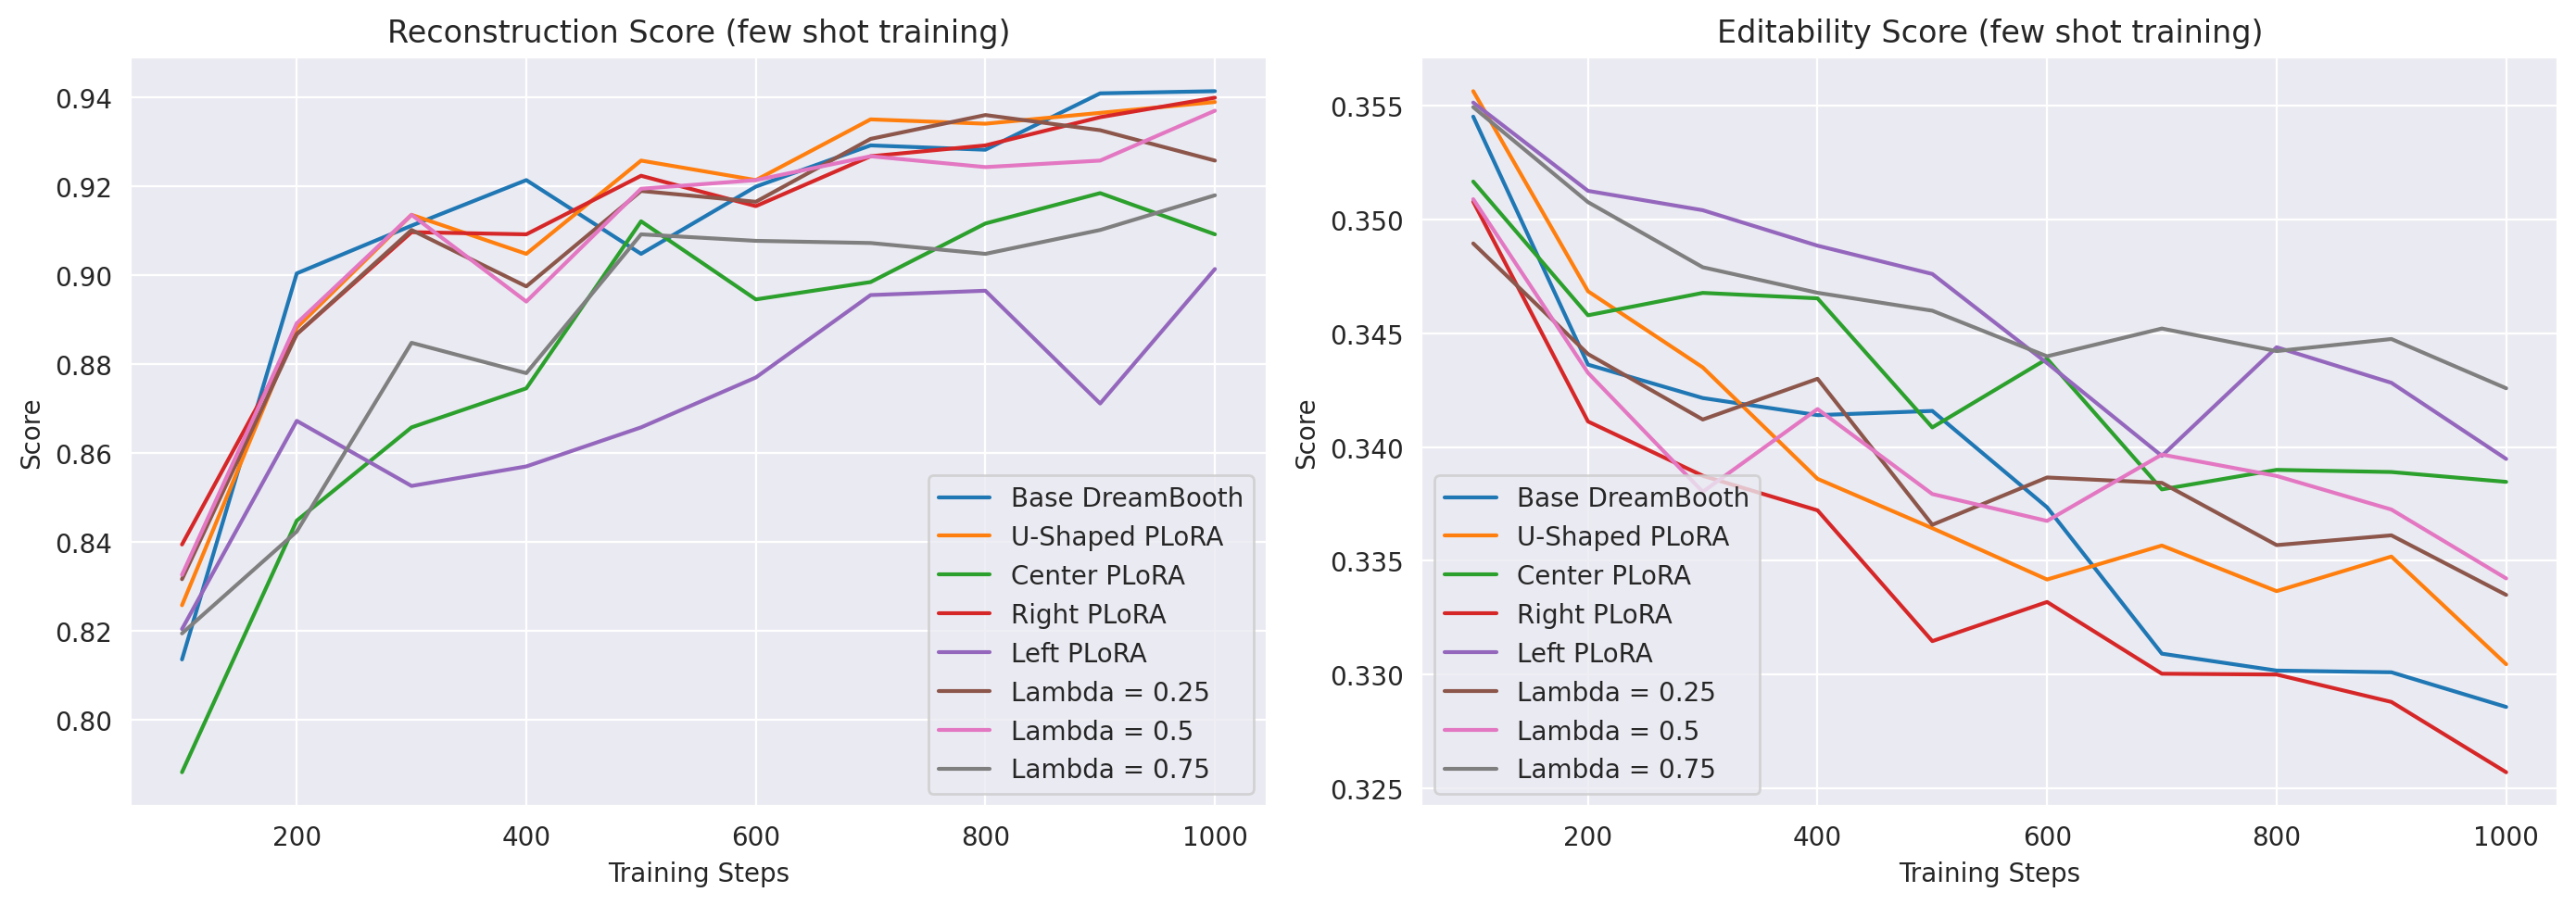

In [8]:
base_rec_few = {100: 0.8134765625,
 200: 0.900390625,
 300: 0.9111328125,
 400: 0.92138671875,
 500: 0.90478515625,
 600: 0.919921875,
 700: 0.92919921875,
 800: 0.92822265625,
 900: 0.94091796875,
 1000: 0.94140625}

base_edit_few = {100: 0.35452368951612906,
 200: 0.34362005418346775,
 300: 0.3421512726814516,
 400: 0.34139916204637094,
 500: 0.34158423639112906,
 600: 0.3373472152217742,
 700: 0.3309129284274194,
 800: 0.33016869329637094,
 900: 0.3300938760080645,
 1000: 0.32856996597782256}

u_shaped_rec = {100: 0.82568359375,
 200: 0.88818359375,
 300: 0.91357421875,
 400: 0.90478515625,
 500: 0.92578125,
 600: 0.92138671875,
 700: 0.93505859375,
 800: 0.93408203125,
 900: 0.9365234375,
 1000: 0.93896484375}

center_rec = {100: 0.7880859375,
 200: 0.8447265625,
 300: 0.86572265625,
 400: 0.87451171875,
 500: 0.912109375,
 600: 0.89453125,
 700: 0.8984375,
 800: 0.91162109375,
 900: 0.91845703125,
 1000: 0.9091796875}


u_shaped_edit = {100: 0.3556420110887097,
 200: 0.34684507308467744,
 300: 0.34349798387096775,
 400: 0.33859942036290325,
 500: 0.3364297190020161,
 600: 0.3341733870967742,
 700: 0.3356657951108871,
 800: 0.33366147933467744,
 900: 0.33518145161290325,
 1000: 0.3304482736895161}

center_edit = {100: 0.3516688193044355,
 200: 0.3457897555443548,
 300: 0.3467741935483871,
 400: 0.34653399067540325,
 500: 0.3408596900201613,
 600: 0.3438760080645161,
 700: 0.338134765625,
 800: 0.3389931955645161,
 900: 0.33889868951612906,
 1000: 0.3384655367943548}

right_rec_few = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

right_edit_few = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}


left_rec_few = {100: 0.8203125,
 200: 0.8671875,
 300: 0.8525390625,
 400: 0.85693359375,
 500: 0.86572265625,
 600: 0.876953125,
 700: 0.8955078125,
 800: 0.896484375,
 900: 0.87109375,
 1000: 0.9013671875}

left_edit_few = {100: 0.3551419165826613,
 200: 0.35125929309475806,
 300: 0.3504087386592742,
 400: 0.3488493888608871,
 500: 0.3476050592237903,
 600: 0.34368699596774194,
 700: 0.33960748487903225,
 800: 0.34438397807459675,
 900: 0.34282069052419356,
 1000: 0.3394736013104839}

base_rec_one = {100: 0.818359375,
 200: 0.91015625,
 300: 0.93017578125,
 400: 0.93408203125,
 500: 0.9384765625,
 600: 0.94140625,
 700: 0.9384765625,
 800: 0.93603515625,
 900: 0.9375,
 1000: 0.93310546875}

base_edit_one = {100: 0.35202715473790325,
 200: 0.3436239919354839,
 300: 0.3357484879032258,
 400: 0.33355909778225806,
 500: 0.32954652847782256,
 600: 0.3252780052923387,
 700: 0.3181664251512097,
 800: 0.3164712229082661,
 900: 0.3006493353074597,
 1000: 0.2898283927671371}



left_rec_one = {100: 0.818359375,
 200: 0.84423828125,
 300: 0.88916015625,
 400: 0.90576171875,
 500: 0.91259765625,
 600: 0.9091796875,
 700: 0.896484375,
 800: 0.88671875,
 900: 0.9091796875,
 1000: 0.88916015625}

left_edit_one = {100: 0.3535825667842742,
 200: 0.3529170866935484,
 300: 0.3498495778729839,
 400: 0.34464780745967744,
 500: 0.33411432081653225,
 600: 0.33264947706653225,
 700: 0.3208578786542339,
 800: 0.3147484564012097,
 900: 0.3076290007560484,
 1000: 0.3042760049143145}

right_rec_one = {100: 0.8505859375,
 200: 0.91015625,
 300: 0.92724609375,
 400: 0.93408203125,
 500: 0.93603515625,
 600: 0.92822265625,
 700: 0.94287109375,
 800: 0.94775390625,
 900: 0.94580078125,
 1000: 0.92578125}

right_edit_one = {100: 0.3502157888104839,
 200: 0.3403162802419355,
 300: 0.33690618699596775,
 400: 0.33012144027217744,
 500: 0.32443926411290325,
 600: 0.32117486769153225,
 700: 0.3139549993699597,
 800: 0.30753843245967744,
 900: 0.29908014112903225,
 1000: 0.2970088835685484}

u_shaped_rec_one = {100: 0.8251953125,
 200: 0.9169921875,
 300: 0.93701171875,
 400: 0.935546875,
 500: 0.93701171875,
 600: 0.93017578125,
 700: 0.94287109375,
 800: 0.93896484375,
 900: 0.93994140625,
 1000: 0.9326171875}

u_shaped_edit_one = {100: 0.35584283644153225,
 200: 0.3450258316532258,
 300: 0.3384497857862903,
 400: 0.33523658014112906,
 500: 0.32985170425907256,
 600: 0.33094049269153225,
 700: 0.3192079605594758,
 800: 0.3097750756048387,
 900: 0.3085976877520161,
 1000: 0.29789487777217744}

center_rec_one = {100: 0.771484375,
 200: 0.88134765625,
 300: 0.896484375,
 400: 0.90380859375,
 500: 0.8916015625,
 600: 0.85888671875,
 700: 0.8642578125,
 800: 0.8505859375,
 900: 0.87353515625,
 1000: 0.87548828125}

center_edit_one = {100: 0.35044024067540325,
 200: 0.3490502142137097,
 300: 0.3458527595766129,
 400: 0.3364769720262097,
 500: 0.3299678679435484,
 600: 0.3268885458669355,
 700: 0.31603807018649194,
 800: 0.3070718088457661,
 900: 0.29488446635584675,
 1000: 0.29777674521169356}

tlora_rec_few = {100: 0.78125,
 200: 0.7939453125,
 300: 0.84326171875,
 400: 0.88134765625,
 500: 0.9072265625,
 600: 0.92529296875,
 700: 0.916015625,
 800: 0.93115234375,
 900: 0.921875,
 1000: 0.92724609375}

tlora_edit_few = {100: 0.34933373235887094,
 200: 0.3476365612399194,
 300: 0.3415881741431452,
 400: 0.33803632182459675,
 500: 0.33280698714717744,
 600: 0.32923150831653225,
 700: 0.32802655619959675,
 800: 0.3269909274193548,
 900: 0.3249708606350806,
 1000: 0.3231319304435484}

tlora_rec_one = {100: 0.77099609375,
 200: 0.80322265625,
 300: 0.8623046875,
 400: 0.8916015625,
 500: 0.91259765625,
 600: 0.90185546875,
 700: 0.92236328125,
 800: 0.919921875,
 900: 0.91748046875,
 1000: 0.92041015625}

tlora_edit_one = {100: 0.3512632308467742,
 200: 0.3482272240423387,
 300: 0.3406706779233871,
 400: 0.33644940776209675,
 500: 0.33106256300403225,
 600: 0.3248999810987903,
 700: 0.32201360887096775,
 800: 0.3194186302923387,
 900: 0.3173001197076613,
 1000: 0.3158687468497984}


# lambda = 0.25
lambda25_rec = {100: 0.83154296875,
 200: 0.88671875,
 300: 0.91015625,
 400: 0.8974609375,
 500: 0.9189453125,
 600: 0.91650390625,
 700: 0.9306640625,
 800: 0.93603515625,
 900: 0.9326171875,
 1000: 0.92578125}

# lambda = 0.5
lambda50_rec = {100: 0.83251953125,
 200: 0.88916015625,
 300: 0.91357421875,
 400: 0.89404296875,
 500: 0.91943359375,
 600: 0.92138671875,
 700: 0.9267578125,
 800: 0.92431640625,
 900: 0.92578125,
 1000: 0.93701171875}

# lambda = 0.25
lambda25_rec = {100: 0.83154296875,
 200: 0.88671875,
 300: 0.91015625,
 400: 0.8974609375,
 500: 0.9189453125,
 600: 0.91650390625,
 700: 0.9306640625,
 800: 0.93603515625,
 900: 0.9326171875,
 1000: 0.92578125}

# lambda = 0.5
lambda50_rec = {100: 0.83251953125,
 200: 0.88916015625,
 300: 0.91357421875,
 400: 0.89404296875,
 500: 0.91943359375,
 600: 0.92138671875,
 700: 0.9267578125,
 800: 0.92431640625,
 900: 0.92578125,
 1000: 0.93701171875}

# lambda = 0.75
lambda75_rec = {100: 0.8193359375,
 200: 0.84228515625,
 300: 0.884765625,
 400: 0.8779296875,
 500: 0.9091796875,
 600: 0.90771484375,
 700: 0.9072265625,
 800: 0.90478515625,
 900: 0.91015625,
 1000: 0.91796875}

# lambda = 0.25
lambda25_edit = {100: 0.3489478326612903,
 200: 0.34408470892137094,
 300: 0.3412062121975806,
 400: 0.3429978893649194,
 500: 0.33657935357862906,
 600: 0.3386584866431452,
 700: 0.33842222152217744,
 800: 0.33568548387096775,
 900: 0.3361146988407258,
 1000: 0.33349609375}

# lambda = 0.50
lambda50_edit = {100: 0.35089308215725806,
 200: 0.3432577809979839,
 300: 0.3380284463205645,
 400: 0.34166692918346775,
 500: 0.3379300025201613,
 600: 0.33674867691532256,
 700: 0.3396665511592742,
 800: 0.3387254284274194,
 900: 0.33724877142137094,
 1000: 0.33422064012096775}


# lambda = 0.75
lambda75_edit = {100: 0.3549410912298387,
 200: 0.3507631363407258,
 300: 0.347900390625,
 400: 0.34677813130040325,
 500: 0.34599058089717744,
 600: 0.34398626512096775,
 700: 0.34520696824596775,
 800: 0.34421465473790325,
 900: 0.3447462512600806,
 1000: 0.3425804876512097}


steps = list(u_shaped_rec.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_few.values(),label="Base DreamBooth")
axs[0].plot(steps, u_shaped_rec.values(), label="U-Shaped PLoRA")
axs[0].plot(steps, center_rec.values(), label="Center PLoRA")
axs[0].plot(steps, right_rec_few.values(), label="Right PLoRA")
axs[0].plot(steps, left_rec_few.values(), label="Left PLoRA")
# axs[0, 0].plot(steps, tlora_rec_few.values(), label="T-LoRA")
axs[0].plot(steps, lambda25_rec.values(), label="Lambda = 0.25")
axs[0].plot(steps, lambda50_rec.values(), label="Lambda = 0.5")
axs[0].plot(steps, lambda75_rec.values(), label="Lambda = 0.75")

axs[0].set_title("Reconstruction Score (few shot training)")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit_few.values(),label="Base DreamBooth")
axs[1].plot(steps, u_shaped_edit.values(), label="U-Shaped PLoRA")
axs[1].plot(steps, center_edit.values(), label="Center PLoRA")
axs[1].plot(steps, right_edit_few.values(), label="Right PLoRA")
axs[1].plot(steps, left_edit_few.values(), label="Left PLoRA")
# axs[0, 1].plot(steps, tlora_edit_few.values(), label="T-LoRA")
axs[1].plot(steps, lambda25_edit.values(), label="Lambda = 0.25")
axs[1].plot(steps, lambda50_edit.values(), label="Lambda = 0.5")
axs[1].plot(steps, lambda75_edit.values(), label="Lambda = 0.75")

axs[1].set_title("Editability Score (few shot training)")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)


# axs[1, 0].plot(steps, base_rec_one.values(),label="Base DreamBooth")
# axs[1, 0].plot(steps, u_shaped_rec_one.values(), label="U-Shaped PLoRA")
# axs[1, 0].plot(steps, center_rec_one.values(), label="Center PLoRA")
# axs[1, 0].plot(steps, right_rec_one.values(), label="Right PLoRA")
# axs[1, 0].plot(steps, left_rec_one.values(), label="Left PLoRA")
# axs[1, 0].plot(steps, tlora_rec_one.values(), label="T-LoRA")

# axs[1, 0].set_title("Reconstruction Score (one shot training)")
# axs[1, 0].set_xlabel("Training Steps")
# axs[1, 0].set_ylabel("Score")
# axs[1, 0].legend()
# axs[1, 0].grid(True)

# # --- Editability subplot ---
# axs[1, 1].plot(steps, base_edit_one.values(),label="Base DreamBooth")
# axs[1, 1].plot(steps, u_shaped_edit_one.values(), label="U-Shaped PLoRA")
# axs[1, 1].plot(steps, center_edit_one.values(), label="Center PLoRA")
# axs[1, 1].plot(steps, right_edit_one.values(), label="Right PLoRA")
# axs[1, 1].plot(steps, left_edit_one.values(), label="Left PLoRA")
# axs[1, 1].plot(steps, tlora_edit_one.values(), label="T-LoRA")

# axs[1, 1].set_title("Editability Score (one shot training)")
# axs[1, 1].set_xlabel("Training Steps")
# axs[1, 1].set_ylabel("Score")
# axs[1, 1].legend()
# axs[1, 1].grid(True)

plt.tight_layout()
plt.show()